# Credit Risk Decisioning Framework for Consumer Lending: Approval, Pricing, and Limit Assignment Strategy


## Executive Summary

Lenders receive large volumes of loan applications and must make consistent risk-sensitive, and profitable credit decisions. For each applicant, the lender must decide whether to approve or decline the application, what interest rate to charge, what loan amount or credit limit to offer, and whether the expected return justifies the credit risk being taken.

This project develops an end-to-end credit risk decisioning framework using LendingClub accepted and rejected loan data. The central question is:


***How should a lender approve, decline, price, and limit new applicants based on expected credit risk and profitability?***


To answer this question, the project combines application data, probability of default modelling, scorecard development, risk-based pricing, expected loss analysis, profitability analysis, hard eligibility rules, limit assignment, and rejected applicant review. The goal is not only to predict default, but to translate model outputs into practical underwriting decisions.

The project uses accepted loan data to build and validate default prediction models because accepted loans have observed repayment outcomes. Rejected loan data is used separately to understand the broader applicant population and to support a reject-inference-style analysis, recognizing that rejected applicants do not have observed performance outcomes.

The final output is a policy engine that segments applicants by risk, pricing adequacy, profitability, affordability, and loan structure. This enables a lender to make more disciplined decisions on approval, repricing, manual review, decline, and credit limit assignment.\

## Business Problem

A lender must make credit decisions before knowing whether an applicant will repay. A weak underwriting policy can lead to excessive defaults and losses, while an overly conservative policy can reject profitable borrowers and reduce growth. A good credit strategy must therefore balance risk, approval volume, pricing, affordability, expected loss, and profitability.

The lender needs a framework that can answer the following practical questions:

- Which applicants should be approved?
- Which applicants should be declined?
- Which applicants should be sent to manual review?
- What probability of default should be assigned to each applicant?
- What interest rate is required to compensate for expected credit risk?
- What loan amount or credit limit should be offered?
- Which risk segments are profitable after expected credit losses and costs?
- Which segments require pricing floors, limit caps, or stricter eligibility rules?
- How should rejected applicants be considered in the analysis?



## Core Decisioning Question

**How can a lender use application data, credit risk modelling, and profitability analysis to design an approval, pricing, and limit strategy for new loan applicants?**

This project answers that question by moving from prediction to policy. The modelling work estimates expected credit risk, while the policy engine translates risk estimates into business decisions.

## Project Objectives

The objective of this project is to build a complete credit decisioning framework that can support new applicant underwriting. Specifically, the project aims to:

1. Estimate each applicant's probability of default.
2. Segment borrowers into risk bands.
3. Compare the performance of logistic regression, tree-based models, and a WOE/IV scorecard.
4. Evaluate model calibration and out-of-time model stability.
5. Estimate expected credit losses using probability of default and loss assumptions.
6. Assess profitability by borrower segment.
7. Create risk-based pricing floors based on break-even required APR.
8. Assign risk-based and affordability-based credit limits.
9. Apply hard eligibility and manual review rules.
10. Simulate the risk profile of rejected applicants using a common-feature model.
11. Build a final approval, repricing, manual review, decline, and exception-only policy matrix.

## Analytical Questions

The project is structured around the following sub-questions:

- What applicant characteristics are most predictive of default?
- What is the expected probability of default for each applicant?
- How well do logistic regression, scorecard, and tree-based models perform?
- How should probability of default estimates be calibrated?
- How should borrowers be segmented into risk bands?
- What approval strategy balances risk, volume, and profitability?
- Which borrowers are underpriced relative to expected risk and cost?
- What interest rate should different risk bands receive?
- What loan amounts or limits should be assigned to different borrowers?
- How much profit or loss is expected by segment?
- How should hard eligibility rules modify model-based decisions?
- How should rejected applicants be treated, given that they have no observed repayment outcomes?

In [ ]:
import os
import gc
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, average_precision_score, confusion_matrix, classification_report

from sklearn.calibration import calibration_curve

from scipy.special import logit, expit


## Dataset Overview

This project uses a subset of LendingClub loan application data between 2007 and 2013. The dataset contains two main files:

1. **Accepted loan dataset**
2. **Rejected loan dataset**

The accepted loan dataset contains applications that were approved and originated. These records include application characteristics, loan terms, credit attributes, interest rates, loan status, payment outcomes, recoveries, and other performance-related fields. Because accepted loans have observed repayment outcomes, this dataset is used to build and validate the probability of default model.

The rejected loan dataset contains applications that were declined. These records are useful because they provide visibility into the broader applicant funnel, including applicants who did not pass LendingClub's underwriting criteria. However, rejected applicants do not have observed repayment outcomes. As a result, the rejected dataset cannot be used directly to train a supervised default model. It is used for accepted-versus-rejected comparison and for a separate reject-inference-style simulation.

The accepted dataset is therefore the primary modelling dataset, while the rejected dataset is used for applicant population analysis and rejected applicant risk simulation.

# 1. Data Loading, Cleaning, and Target Definition

## 1.1 Load accepted and rejected datasets

In [ ]:


accepted_file_path = os.path.join(BASE_PATH, 'Accepted_2007_to_2014.csv')
rejected_file_path = os.path.join(BASE_PATH, 'Rejected_2007_to_2014.csv')


accepted_raw = pd.read_csv (accepted_file_path, low_memory=False)
rejected_raw = pd.read_csv (rejected_file_path, low_memory=False)


gc.collect()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [ ]:
accepted = accepted_raw.copy()
rejected = rejected_raw.copy()

### Accepted vs Rejected Data Treatment

The accepted and rejected datasets serve different analytical purposes.

### Accepted Loans

Accepted loans are used for supervised credit risk modelling because they contain observed loan outcomes. These outcomes allow the project to define a binary default target and train models that estimate the probability of default.

Accepted loans are used for:

- Target definition
- Train, validation, and test splitting
- Probability of default modelling
- Model validation
- Calibration analysis
- WOE/IV scorecard development
- LGD and profitability analysis
- Approval, pricing, and limit policy design

### Rejected Loans

Rejected loans do not have observed repayment performance. This means we do not know whether those applicants would have repaid or defaulted if approved. Therefore, rejected loans are not used directly in the main supervised PD model.

Rejected loans are used for:

- Comparing accepted and rejected applicant profiles
- Assessing risk score and DTI data quality
- Identifying scorable and unscorable rejected applicants
- Running a separate common-feature reject-inference-style simulation
- Estimating whether any rejected applicants may represent missed lending opportunities

The rejected applicant analysis is treated as directional. It supports underwriting insight, but it does not provide validated default outcomes for rejected borrowers.

## 1.2 Standardize and Clean  Accepted Dataset Columns

In [ ]:
#Helper Functions
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace(".", "_", regex=False)
    )
    return df


def clean_percentage_column(series):
    return (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace("nan", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )


def clean_term_column(series):
    return (
        series.astype(str)
        .str.extract(r"(\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
    )


def clean_emp_length(series):
    s = series.astype(str).str.lower().str.strip()

    s = (
        s.str.replace("years", "", regex=False)
        .str.replace("year", "", regex=False)
        .str.replace("+", "", regex=False)
        .str.replace("< 1", "0", regex=False)
        .str.replace("n/a", "", regex=False)
        .str.strip()
    )

    return pd.to_numeric(s, errors="coerce")


def numeric_distribution_report(data, cols):
    rows = []

    for col in cols:
        s = pd.to_numeric(data[col], errors="coerce")

        rows.append({
            "column": col,
            "missing_rate": s.isna().mean(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p01": s.quantile(0.01),
            "p05": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.median(),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max()
        })

    return pd.DataFrame(rows)


def missing_report(data, dataset_name):
    report = pd.DataFrame({
        "column": data.columns,
        "missing_count": data.isna().sum().values,
        "missing_rate": data.isna().mean().values
    })

    report["dataset"] = dataset_name

    return report.sort_values("missing_rate", ascending=False)

In [ ]:
accepted = clean_column_names(accepted)

accepted["loan_term"] = clean_term_column(accepted["term"])

accepted["int_rate"] = clean_percentage_column(accepted["int_rate"])

accepted["revol_util"] = clean_percentage_column(accepted["revol_util"])

accepted["employment_length_in_years"] = clean_emp_length(accepted["emp_length"])

In [ ]:
## Parse accepted date fields
date_cols_accepted = [
    "issue_d",
    "earliest_cr_line",
    "last_pymnt_d",
    "next_pymnt_d",
    "last_credit_pull_d"
]

for col in date_cols_accepted:
    if col in accepted.columns:
        accepted[col] = pd.to_datetime(accepted[col], errors="coerce")


/tmp/ipykernel_773/4114451245.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accepted[col] = pd.to_datetime(accepted[col], errors="coerce")
/tmp/ipykernel_773/4114451245.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accepted[col] = pd.to_datetime(accepted[col], errors="coerce")
/tmp/ipykernel_773/4114451245.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  accepted[col] = pd.to_datetime(accepted[col], errors="coerce")
/tmp/ipykernel_773/4114451245.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateut

In [ ]:
##Create core accepted features

accepted["issue_year"] = accepted["issue_d"].dt.year

accepted["fico_score"] = (
    accepted["fico_range_low"] + accepted["fico_range_high"]
) / 2

accepted["loan_status_clean"] = accepted["loan_status"].astype(str).str.strip()

## 1.3 Define resolved loan population

### Target Definition

The modelling target is a binary default indicator created from the accepted loan status.

The target is defined as:

- **1 = Default / Bad loan**
- **0 = Non-default / Good loan**


Loans are classified as bad if they reached a default-like outcome, such as being charged off or defaulted. Loans are classified as good if they were fully paid.


The target is designed to answer the underwriting question:


**At the time of application, how likely is this borrower to become a bad loan?**


Only resolved loan outcomes are used for the main supervised modelling process. Loans with unresolved or active statuses are excluded from the core PD model because their final repayment outcome is not yet known.


This approach ensures that the model is trained on loans with clear observed performance outcomes.




In [ ]:
resolved_good_statuses = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

resolved_bad_statuses = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

accepted_resolved = accepted[
    accepted["loan_status_clean"].isin(
        resolved_good_statuses + resolved_bad_statuses
    )
].copy()

accepted_resolved["target"] = np.where(
    accepted_resolved["loan_status_clean"].isin(resolved_bad_statuses),
    1,
    0
)

In [ ]:
#target distribution check

target_check = (
    accepted_resolved.groupby("loan_status_clean")
    .agg(
        loan_count=("target", "count"),
        default_rate=("target", "mean")
    )
    .reset_index()
    .sort_values("loan_count", ascending=False)
)

target_check

,loan_status_clean,loan_count,default_rate
4,Fully Paid,374560,0.0000
0,Charged Off,76499,1.0000
3,Does not meet the credit policy. Status:Fully ...,1988,0.0000
2,Does not meet the credit policy. Status:Charge...,761,1.0000
1,Default,1,1.0000


# 2. Rejected Data Cleaning and Accepted vs Rejected Overview

## 2.1 Cleaning Rejected Dataset

In [ ]:
rejected = clean_column_names(rejected)

In [ ]:
rejected_rename_map = {
    "amount_requested": "loan_amnt",
    "application_date": "app_date",
    "risk_score": "fico_score",
    "debt_to_income_ratio": "dti",
    "zip_code": "zip_code",
    "state": "addr_state",
    "employment_length": "employment_length_in_years"
}

rejected = rejected.rename(
    columns={
        old: new
        for old, new in rejected_rename_map.items()
        if old in rejected.columns
    }
)

In [ ]:
rejected_clean = rejected.copy()

if "loan_amnt" in rejected_clean.columns:
    rejected_clean["loan_amnt"] = (
        rejected_clean["loan_amnt"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace("nan", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

if "dti" in rejected_clean.columns:
    rejected_clean["dti_raw"] = (
        rejected_clean["dti"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace("nan", np.nan)
        .pipe(pd.to_numeric, errors="coerce")
    )

    rejected_clean["dti_negative_flag"] = (
        rejected_clean["dti_raw"] < 0
    ).astype(int)

    rejected_clean["dti_extreme_flag"] = (
        rejected_clean["dti_raw"] > 100
    ).astype(int)

    rejected_clean["dti_clean"] = rejected_clean["dti_raw"]
    rejected_clean.loc[rejected_clean["dti_clean"] < 0, "dti_clean"] = np.nan

    rejected_clean["dti_capped_100"] = rejected_clean["dti_clean"].clip(
        lower=0,
        upper=100
    )

if "fico_score" in rejected_clean.columns:
    rejected_clean["fico_score_raw"] = pd.to_numeric(
        rejected_clean["fico_score"],
        errors="coerce"
    )

    rejected_clean["risk_score_missing_flag"] = (
        rejected_clean["fico_score_raw"].isna()
    ).astype(int)

    rejected_clean["risk_score_invalid_flag"] = (
        (rejected_clean["fico_score_raw"] <= 0) |
        (rejected_clean["fico_score_raw"] > 850)
    ).astype(int)

    rejected_clean["fico_score_clean"] = rejected_clean["fico_score_raw"]
    rejected_clean.loc[
        rejected_clean["risk_score_invalid_flag"] == 1,
        "fico_score_clean"
    ] = np.nan

if "employment_length_in_years" in rejected_clean.columns:
    rejected_clean["employment_length_in_years"] = clean_emp_length(
        rejected_clean["employment_length_in_years"]
    )

if "app_date" in rejected_clean.columns:
    rejected_clean["app_date"] = pd.to_datetime(
        rejected_clean["app_date"],
        errors="coerce"
    )
    rejected_clean["application_year"] = rejected_clean["app_date"].dt.year

In [ ]:
#Rejected score quality
rejected_score_quality = pd.DataFrame({
    "metric": [
        "row_count",
        "missing_raw_score_count",
        "missing_raw_score_rate",
        "invalid_score_count",
        "invalid_score_rate",
        "missing_or_invalid_score_count",
        "missing_or_invalid_score_rate",
        "valid_score_count",
        "valid_score_rate",
        "valid_score_median",
        "valid_score_p25",
        "valid_score_p75"
    ],
    "value": [
        len(rejected_clean),
        rejected_clean["risk_score_missing_flag"].sum(),
        rejected_clean["risk_score_missing_flag"].mean(),
        rejected_clean["risk_score_invalid_flag"].sum(),
        rejected_clean["risk_score_invalid_flag"].mean(),
        (
            (rejected_clean["risk_score_missing_flag"] == 1) |
            (rejected_clean["risk_score_invalid_flag"] == 1)
        ).sum(),
        (
            (rejected_clean["risk_score_missing_flag"] == 1) |
            (rejected_clean["risk_score_invalid_flag"] == 1)
        ).mean(),
        rejected_clean["fico_score_clean"].notna().sum(),
        rejected_clean["fico_score_clean"].notna().mean(),
        rejected_clean["fico_score_clean"].median(),
        rejected_clean["fico_score_clean"].quantile(0.25),
        rejected_clean["fico_score_clean"].quantile(0.75)
    ]
})

rejected_score_quality

,metric,value
0,row_count,"3,450,133.0000"
1,missing_raw_score_count,"302,274.0000"
2,missing_raw_score_rate,0.0876
3,invalid_score_count,"92,869.0000"
4,invalid_score_rate,0.0269
5,missing_or_invalid_score_count,"395,143.0000"
6,missing_or_invalid_score_rate,0.1145
7,valid_score_count,"3,054,990.0000"
8,valid_score_rate,0.8855
9,valid_score_median,643.0000


In [ ]:
# rejected DTI quality

rejected_dti_quality = pd.DataFrame({
    "metric": [
        "row_count",
        "negative_dti_count",
        "negative_dti_rate",
        "dti_above_100_count",
        "dti_above_100_rate",
        "clean_dti_missing_rate",
        "clean_dti_median",
        "clean_dti_p75",
        "clean_dti_p95",
        "clean_dti_p99"
    ],
    "value": [
        len(rejected_clean),
        rejected_clean["dti_negative_flag"].sum(),
        rejected_clean["dti_negative_flag"].mean(),
        rejected_clean["dti_extreme_flag"].sum(),
        rejected_clean["dti_extreme_flag"].mean(),
        rejected_clean["dti_clean"].isna().mean(),
        rejected_clean["dti_clean"].median(),
        rejected_clean["dti_clean"].quantile(0.75),
        rejected_clean["dti_clean"].quantile(0.95),
        rejected_clean["dti_clean"].quantile(0.99)
    ]
})

rejected_dti_quality

,metric,value
0,row_count,"3,450,133.0000"
1,negative_dti_count,"265,406.0000"
2,negative_dti_rate,0.0769
3,dti_above_100_count,"93,315.0000"
4,dti_above_100_rate,0.0270
5,clean_dti_missing_rate,0.0769
6,clean_dti_median,18.2100
7,clean_dti_p75,32.8000
8,clean_dti_p95,67.6300
9,clean_dti_p99,446.5722


## 2.2 Accepted Vs rejected comparison using cleaned variables

In [ ]:
accepted_compare = accepted_resolved.copy()
rejected_compare = rejected_clean.copy()

accepted_compare["source"] = "Accepted"
rejected_compare["source"] = "Rejected"

accepted_compare["fico_for_comparison"] = accepted_compare["fico_score"]
rejected_compare["fico_for_comparison"] = rejected_compare["fico_score_clean"]

accepted_compare["dti_for_comparison"] = accepted_compare["dti"]
rejected_compare["dti_for_comparison"] = rejected_compare["dti_capped_100"]

accepted_rejected_compare_cols = [
    "loan_amnt",
    "fico_for_comparison",
    "dti_for_comparison",
    "employment_length_in_years"
]

accepted_rejected_compare_cols = [
    col for col in accepted_rejected_compare_cols
    if col in accepted_compare.columns and col in rejected_compare.columns
]

accepted_rejected_comparison = pd.concat(
    [
        accepted_compare[accepted_rejected_compare_cols + ["source"]],
        rejected_compare[accepted_rejected_compare_cols + ["source"]]
    ],
    ignore_index=True
)

accepted_rejected_summary_rows = []

for col in accepted_rejected_compare_cols:
    temp = (
        accepted_rejected_comparison.groupby("source")[col]
        .agg(
            applicant_count="count",
            missing_rate=lambda x: x.isna().mean(),
            mean="mean",
            median="median",
            p25=lambda x: x.quantile(0.25),
            p75=lambda x: x.quantile(0.75),
            p95=lambda x: x.quantile(0.95)
        )
        .reset_index()
    )

    temp["variable"] = col
    accepted_rejected_summary_rows.append(temp)

accepted_rejected_summary = pd.concat(
    accepted_rejected_summary_rows,
    ignore_index=True
)

accepted_rejected_summary = accepted_rejected_summary[
    [
        "variable",
        "source",
        "applicant_count",
        "missing_rate",
        "mean",
        "median",
        "p25",
        "p75",
        "p95"
    ]
]

accepted_rejected_summary

,variable,source,applicant_count,missing_rate,mean,median,p25,p75,p95
0,loan_amnt,Accepted,453809,0.0000,"14,160.6158","12,000.0000","8,000.0000","20,000.0000","30,000.0000"
1,loan_amnt,Rejected,3450133,0.0000,"12,752.5075","10,000.0000","4,000.0000","20,000.0000","35,000.0000"
2,fico_for_comparison,Accepted,453809,0.0000,698.1980,692.0000,677.0000,712.0000,762.0000
3,fico_for_comparison,Rejected,3054990,0.1145,634.9057,643.0000,593.0000,681.0000,736.0000
4,dti_for_comparison,Accepted,453809,0.0000,17.1458,16.8000,11.3000,22.7000,30.6700
5,dti_for_comparison,Rejected,3184727,0.0769,23.4086,18.2100,7.4900,32.8000,67.6300


## 2.3  Rejected scorable / unscorable overview

In [ ]:
rejected_clean["rejected_scorable_flag"] = np.where(
    (rejected_clean["fico_score_clean"].notna()) &
    (rejected_clean["dti_capped_100"].notna()),
    1,
    0
)

rejected_clean["rejected_high_caution_flag"] = np.where(
    (rejected_clean["risk_score_invalid_flag"] == 1) |
    (rejected_clean["dti_negative_flag"] == 1) |
    (rejected_clean["dti_extreme_flag"] == 1),
    1,
    0
)

rejected_clean["rejected_scoring_group"] = np.select(
    [
        rejected_clean["risk_score_missing_flag"] == 1,
        rejected_clean["risk_score_invalid_flag"] == 1,
        rejected_clean["dti_negative_flag"] == 1,
        rejected_clean["dti_extreme_flag"] == 1,
        rejected_clean["rejected_scorable_flag"] == 1
    ],
    [
        "Unscorable - Missing Risk Score",
        "Unscorable - Invalid Risk Score",
        "Unscorable - Negative DTI",
        "Scorable with Caution - Extreme DTI",
        "Scorable"
    ],
    default="Review"
)

In [ ]:
rejected_scoring_group_summary = (
    rejected_clean.groupby("rejected_scoring_group")
    .agg(
        applicant_count=("loan_amnt", "count"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_fico=("fico_score_clean", "mean"),
        median_fico=("fico_score_clean", "median"),
        avg_dti_capped_100=("dti_capped_100", "mean"),
        median_dti_capped_100=("dti_capped_100", "median")
    )
    .reset_index()
)

rejected_scoring_group_summary["population_share"] = (
    rejected_scoring_group_summary["applicant_count"] / len(rejected_clean)
)

rejected_scoring_group_summary

,rejected_scoring_group,applicant_count,avg_loan_amount,avg_fico,median_fico,avg_dti_capped_100,median_dti_capped_100,population_share
0,Scorable,2958786,"12,722.5632",635.2430,643.0000,21.8684,18.3500,0.8576
1,Scorable with Caution - Extreme DTI,88855,"11,938.6848",625.0376,635.0000,100.0000,100.0000,0.0258
2,Unscorable - Invalid Risk Score,92869,"8,542.2706",NaN,NaN,3.8208,0.0000,0.0269
3,Unscorable - Missing Risk Score,302274,"14,719.0096",NaN,NaN,12.8750,0.0000,0.0876
4,Unscorable - Negative DTI,7349,"6,967.9310",618.4167,611.0000,NaN,NaN,0.0021


# 3. Feature Engineering, Leakage Controls, and Feature Governance

In [ ]:
def numeric_distribution_report(data, cols):
    rows = []

    for col in cols:
        s = pd.to_numeric(data[col], errors="coerce")

        rows.append({
            "column": col,
            "missing_rate": s.isna().mean(),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "p01": s.quantile(0.01),
            "p05": s.quantile(0.05),
            "p25": s.quantile(0.25),
            "median": s.median(),
            "p75": s.quantile(0.75),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max()
        })

    return pd.DataFrame(rows)

In [ ]:
accepted_model_base = accepted_resolved.copy()

## 3.1 Data Leakage Controls

Credit risk models should only use information that would be available at or before the point of underwriting. Variables that are created after loan approval, after repayment begins, or after default occurs can leak future information into the model and artificially improve performance.

To avoid leakage, this project separates variables into the following groups:

1. **Application-time features**
2. **LendingClub decision outputs**
3. **Post-origination performance fields**
4. **Outcome and target variables**
5. **Identifiers and free-text fields**
6. **Business metadata**

Only application-time borrower and credit attributes are used in the primary PD model and scorecard. Variables such as loan status, recoveries, total payments, outstanding principal, collections, recoveries, and other post-origination performance fields are excluded from model training.

Interest rate, grade, and sub-grade are also excluded from the primary PD model because they are LendingClub decision outputs. They may contain information from LendingClub's own underwriting process and would therefore create decision leakage if used to predict default for new applicants.

These fields are used later for pricing and profitability analysis, but not as predictive inputs in the primary application PD model.

This leakage control is critical because the purpose of the model is to support decisions for new applicants at the time of application.

In [ ]:
## Application time Engineerd features

def add_application_features(data):
    data = data.copy()

    data["monthly_income"] = data["annual_inc"] / 12
    data["loan_to_income"] = data["loan_amnt"] / data["annual_inc"]
    data["installment_to_income"] = (
        data["installment"] * 12 / data["annual_inc"]
    )
    data["revol_bal_to_income"] = data["revol_bal"] / data["annual_inc"]

    if "total_bal_ex_mort" in data.columns:
        data["total_bal_to_income"] = (
            data["total_bal_ex_mort"] / data["annual_inc"]
        )

    if "earliest_cr_line" in data.columns and "issue_d" in data.columns:
        data["credit_history_months"] = (
            (data["issue_d"].dt.year - data["earliest_cr_line"].dt.year) * 12
            + (data["issue_d"].dt.month - data["earliest_cr_line"].dt.month)
        )

        data["credit_history_months"] = data["credit_history_months"].clip(
            lower=0
        )

    return data

In [ ]:
accepted_model_base = add_application_features(accepted_model_base)

In [ ]:
## Add missing flags and no event flags

important_missing_flag_cols = [
    "annual_inc",
    "dti",
    "fico_score",
    "employment_length_in_years",
    "revol_util"
]

for col in important_missing_flag_cols:
    if col in accepted_model_base.columns:
        accepted_model_base[f"{col}_missing_flag"] = (
            accepted_model_base[col].isna().astype(int)
        )

In [ ]:
months_since_cols = [
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_last_major_derog",
    "mths_since_recent_bc_dlq",
    "mths_since_recent_revol_delinq"
]

for col in months_since_cols:
    if col in accepted_model_base.columns:
        accepted_model_base[f"{col}_no_event_flag"] = (
            accepted_model_base[col].isna().astype(int)
        )

        accepted_model_base[col] = accepted_model_base[col].fillna(999)

In [ ]:
## Define leakage and excluded columns

outcome_cols = [
    "loan_status",
    "loan_status_clean",
    "target"
]

post_origination_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d"
]

lendingclub_decision_cols = [
    "int_rate",
    "installment",
    "grade",
    "sub_grade"
]

id_text_cols = [
    "id",
    "member_id",
    "url",
    "desc",
    "emp_title",
    "title",
    "zip_code"
]

## 3.4 Out-of-time train / validation / test split

In [ ]:
#Create train, validation, and test split before model imputation to fix possible leakage issues

year_summary = (
    accepted_model_base.groupby("issue_year")
    .agg(
        loan_count=("target", "count"),
        default_rate=("target", "mean")
    )
    .reset_index()
    .sort_values("issue_year")
)

year_summary

,issue_year,loan_count,default_rate
0,2007,603,0.2620
1,2008,2393,0.2073
2,2009,5281,0.1369
3,2010,12537,0.1401
4,2011,21721,0.1518
5,2012,53367,0.1620
6,2013,134804,0.1560
7,2014,223103,0.1845


In [ ]:
train_years = list(range(2007, 2013))
valid_years = [2013]
test_years = [2014]

train_df = accepted_model_base[
    accepted_model_base["issue_year"].isin(train_years)
].copy()

valid_df = accepted_model_base[
    accepted_model_base["issue_year"].isin(valid_years)
].copy()

test_df = accepted_model_base[
    accepted_model_base["issue_year"].isin(test_years)
].copy()

In [ ]:
split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "min_year": [
        train_df["issue_year"].min(),
        valid_df["issue_year"].min(),
        test_df["issue_year"].min()
    ],
    "max_year": [
        train_df["issue_year"].max(),
        valid_df["issue_year"].max(),
        test_df["issue_year"].max()
    ],
    "loan_count": [
        len(train_df),
        len(valid_df),
        len(test_df)
    ],
    "default_rate": [
        train_df["target"].mean(),
        valid_df["target"].mean(),
        test_df["target"].mean()
    ]
})

split_summary

,split,min_year,max_year,loan_count,default_rate
0,Train,2007,2012,95902,0.1572
1,Validation,2013,2013,134804,0.1560
2,Test,2014,2014,223103,0.1845


## Train-based caps and log transformations

In [ ]:
cap_candidate_cols = [
    "annual_inc",
    "revol_bal",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "loan_to_income",
    "installment_to_income",
    "revol_bal_to_income",
    "total_bal_to_income",
    "open_acc",
    "total_acc",
    "revol_util",
    "credit_history_months"
]

cap_candidate_cols = [
    col for col in cap_candidate_cols
    if col in train_df.columns
]

In [ ]:
## calculate train only caps

cap_values = {}

for col in cap_candidate_cols:
    cap_values[col] = {
        "lower_cap": train_df[col].quantile(0.01),
        "upper_cap": train_df[col].quantile(0.99)
    }

cap_values_df = pd.DataFrame(cap_values).T.reset_index()
cap_values_df = cap_values_df.rename(columns={"index": "column"})

cap_values_df

,column,lower_cap,upper_cap
0,annual_inc,"15,600.0000","234,000.0000"
1,revol_bal,0.0000,"82,057.1900"
2,tot_cur_bal,"3,201.0000","634,440.0000"
3,total_rev_hi_lim,"2,700.0000","117,400.0000"
4,loan_to_income,0.0245,0.5000
5,installment_to_income,0.0092,0.1892
6,revol_bal_to_income,0.0000,0.8633
7,total_bal_to_income,0.0333,2.4821
8,open_acc,2.0000,23.0000
9,total_acc,4.0000,56.0000


In [ ]:
def apply_caps(data, cap_values):
    data = data.copy()

    for col, caps in cap_values.items():
        if col in data.columns:
            data[f"{col}_capped"] = data[col].clip(
                lower=caps["lower_cap"],
                upper=caps["upper_cap"]
            )

    return data

In [ ]:
train_df = apply_caps(train_df, cap_values)
valid_df = apply_caps(valid_df, cap_values)
test_df = apply_caps(test_df, cap_values)

In [ ]:
## add log features

log_candidate_base_cols = [
"annual_inc",
    "revol_bal",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "loan_to_income",
    "installment_to_income",
    "revol_bal_to_income",
    "total_bal_to_income",
    "open_acc",
    "total_acc",
    "revol_util",
    "credit_history_months",
]

In [ ]:
def add_log_features(data, base_cols):
    data = data.copy()

    for col in base_cols:
        capped_col = f"{col}_capped"

        if capped_col in data.columns:
            source_col = capped_col
        elif col in data.columns:
            source_col = col
        else:
            continue

        safe_values = data[source_col].clip(lower=0)
        data[f"log_{col}"] = np.log1p(safe_values)

    return data

In [ ]:
train_df = add_log_features(train_df, log_candidate_base_cols)
valid_df = add_log_features(valid_df, log_candidate_base_cols)
test_df = add_log_features(test_df, log_candidate_base_cols)

In [ ]:
## Add accepted DTI features

def add_dti_features(data):
    data = data.copy()

    data["dti_capped_40"] = data["dti"].clip(lower=0, upper=40)
    data["log_dti"] = np.log1p(data["dti_capped_40"])

    return data

In [ ]:
train_df = add_dti_features(train_df)
valid_df = add_dti_features(valid_df)
test_df = add_dti_features(test_df)

In [ ]:
train_df.head(1)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_term,employment_length_in_years,issue_year,fico_score,loan_status_clean,target,monthly_income,loan_to_income,installment_to_income,revol_bal_to_income,total_bal_to_income,credit_history_months,annual_inc_missing_flag,dti_missing_flag,fico_score_missing_flag,employment_length_in_years_missing_flag,revol_util_missing_flag,mths_since_last_delinq_no_event_flag,mths_since_last_record_no_event_flag,mths_since_last_major_derog_no_event_flag,mths_since_recent_bc_dlq_no_event_flag,mths_since_recent_revol_delinq_no_event_flag,annual_inc_capped,revol_bal_capped,tot_cur_bal_capped,total_rev_hi_lim_capped,loan_to_income_capped,installment_to_income_capped,revol_bal_to_income_capped,total_bal_to_income_capped,open_acc_capped,total_acc_capped,revol_util_capped,credit_history_months_capped,log_annual_inc,log_revol_bal,log_tot_cur_bal,log_total_rev_hi_lim,log_loan_to_income,log_installment_to_income,log_revol_bal_to_income,log_total_bal_to_income,log_open_acc,log_total_acc,log_revol_util,log_credit_history_months,dti_capped_40,log_dti
235629,1077501,NaN,"5,000.0000","5,000.0000","4,975.0000",36 months,10.6500,162.8700,B,B2,NaN,10+ years,RENT,"24,000.0000",Verified,2011-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.6500,0.0000,1985-01-01,735.0000,739.0000,1.0000,999.0000,999.0000,3.0000,0.0000,"13,648.0000",83.7000,9.0000,f,0.0000,0.0000,"5,863.1552","5,833.8400","5,000.0000",863.1600,0.0000,0.0000,0.0000,2015-01-01,171.6200,NaT,2018-12-01,749.0000,745.0000,0.00

In [ ]:
##final feature distribution check

review_cols_after_transform = [
    "annual_inc",
    "annual_inc_capped",
    "log_annual_inc",
    "loan_amnt",
    "log_loan_amnt",
    "dti",
    "dti_capped_40",
    "log_dti",
    "fico_score",
    "loan_to_income",
    "loan_to_income_capped",
    "log_loan_to_income",
    "installment_to_income",
    "installment_to_income_capped",
    "log_installment_to_income",
    "revol_util",
    "revol_util_capped",
    "credit_history_months",
    "log_credit_history_months",
    "log_total_acc",
    "log_revol_util",
    "log_open_acc",
    "log_revol_bal",
    "log_revol_bal_to_income",
]

review_cols_after_transform = [
    col for col in review_cols_after_transform
    if col in train_df.columns
]

train_transform_distribution = numeric_distribution_report(
    train_df,
    review_cols_after_transform
)

train_transform_distribution

,column,missing_rate,mean,std,min,p01,p05,p25,median,p75,p95,p99,max
0,annual_inc,0.0000,"69,461.3711","61,128.1536","1,896.0000","15,600.0000","25,000.0000","42,000.0000","60,000.0000","83,954.0000","142,000.0000","234,000.0000","7,141,778.0000"
1,annual_inc_capped,0.0000,"68,013.5620","38,328.2673","15,600.0000","15,600.0000","25,000.0000","42,000.0000","60,000.0000","83,954.0000","142,000.0000","234,000.0000","234,000.0000"
2,log_annual_inc,0.0000,10.9906,0.5213,9.6551,9.6551,10.1267,10.6454,11.0021,11.3380,11.8636,12.3631,12.3631
3,loan_amnt,0.0000,"12,409.6721","7,882.8876",500.0000,"1,400.0000","2,650.0000","6,000.0000","10,000.0000","16,950.0000","28,100.0000","35,000.0000","35,000.0000"
4,dti,0.0000,15.2029,7.4009,0.0000,0.6500,3.1700,9.6600,15.0900,20.5400,27.7800,32.5600,34.9900
5,dti_capped_40,0.0000,15.2029,7.4009,0.0000,0.6500,3.1700,9.6600,15.0900,20.5400,27.7800,32.5600,34.9900
6,log_dti,0.0000,2.6408,0.6086,0.0000,0.5008,1.4279,2.3665,2.7782,3.0699,3.3597,3.5133,3.5832
7,fico_score,0.0000,708.5611,34.5876,612.0000,662.0000,662.0000,682.0000,702.0000,727.0000,777.0000,802.0000,847.5000
8,loan_to_income,0.0000,0.2029,0.1159,0.0008,0.0245,0.0470,0.1111,0.1846,0.2778,0.4167,0.5000,1.3375
9,loan_to_income_capped,0.0000,0.2025,0.1143,0.0245,0.0245,0.0470,0.1111,0.1846,0.2778,0.4167,0.5000,0.5000


##  Final feature Modelling Feature Set

In [ ]:
missing_cols_summary = pd.DataFrame({
    "feature": accepted_resolved.columns,
    "train_missing_rate": train_df[accepted_resolved.columns].isna().mean().values,
    "valid_missing_rate": valid_df[accepted_resolved.columns].isna().mean().values,
    "test_missing_rate": test_df[accepted_resolved.columns].isna().mean().values
}).sort_values("train_missing_rate", ascending=False)

missing_cols_summary

,feature,train_missing_rate,valid_missing_rate,test_missing_rate
1,member_id,1.0000,1.0000,1.0000
121,sec_app_open_acc,1.0000,1.0000,1.0000
118,sec_app_earliest_cr_line,1.0000,1.0000,1.0000
119,sec_app_inq_last_6mths,1.0000,1.0000,1.0000
123,sec_app_open_act_il,1.0000,1.0000,1.0000
116,sec_app_fico_range_low,1.0000,1.0000,1.0000
115,revol_bal_joint,1.0000,1.0000,1.0000
126,sec_app_collections_12_mths_ex_med,1.0000,1.0000,1.0000
125,sec_app_chargeoff_within_12_mths,1.0000,1.0000,1.0000
127,sec_app_mths_since_last_major_derog,1.0000,1.0000,1.0000


In [ ]:
## Define unstable high-missing features
unstable_high_missing_features = [
    "mo_sin_old_il_acct",
    "mo_sin_old_rev_tl_op",
    "mo_sin_rcnt_rev_tl_op",
    "num_accts_ever_120_pd",
    "num_actv_bc_tl",
    "mo_sin_rcnt_tl",
    "avg_cur_bal",
    "total_rev_hi_lim",
    "tot_cur_bal",
    "pct_tl_nvr_dlq",
    "num_tl_120dpd_2m",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "num_tl_op_past_12m",
    "total_il_high_credit_limit",
    "desc",
    "total_bal_ex_mort",
    "total_bc_limit",
    "mort_acc",
    "acc_open_past_24mths",
    "mths_since_recent_bc",
    "bc_open_to_buy",
    "percent_bc_gt_75",
    "bc_util",
    "mths_since_recent_inq",
    "num_sats",
    "num_bc_sats",
    "num_bc_tl",
    "num_op_rev_tl",
    "tot_coll_amt",
    "num_actv_rev_tl",
    "num_rev_tl_bal_gt_0",
    "num_rev_accts",
    "tot_hi_cred_lim",
    "num_il_tl"
]

In [ ]:
#Final numeric features

final_numeric_features_v1 = [
    # Core application / affordability features
    "loan_amnt",
    "loan_term",
    "fico_score",
    "dti_capped_40",
    "log_dti",
    "log_annual_inc",
    "log_loan_amnt",
    "log_loan_to_income",
    "log_installment_to_income",
    "log_revol_bal",
    "log_revol_bal_to_income",
    "employment_length_in_years",
    "log_credit_history_months",

    # Credit bureau / credit history features
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc_capped",
    "pub_rec",
    "revol_util_capped",
    "total_acc_capped",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "pub_rec_bankruptcies",
    "tax_liens",

    # Missing / no-event flags
    "revol_util_missing_flag",
    "employment_length_in_years_missing_flag",
    "mths_since_last_delinq_no_event_flag",
    "mths_since_last_record_no_event_flag",
    "mths_since_last_major_derog_no_event_flag",
    "mths_since_recent_bc_dlq_no_event_flag",
    "mths_since_recent_revol_delinq_no_event_flag",

        # Event recency severity
    "log_mths_since_last_delinq_capped",
    "log_mths_since_last_record_capped",
    "log_mths_since_last_major_derog_capped",
    "log_mths_since_recent_bc_dlq_capped",
    "log_mths_since_recent_revol_delinq_capped",

        # Additional credit stress indicators
    "chargeoff_within_12_mths",
    "delinq_amnt_positive_flag",
    "log_delinq_amnt",

]

final_numeric_features_v1 = [
    col for col in final_numeric_features_v1
    if col in train_df.columns and col not in unstable_high_missing_features
]

In [ ]:
## final categorical features

final_categorical_features_v1 = [
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type"
]

final_categorical_features_v1 = [
    col for col in final_categorical_features_v1
    if col in train_df.columns
]

In [ ]:
## final feature list

final_features_v1 = final_numeric_features_v1 + final_categorical_features_v1

print("Numeric features:", len(final_numeric_features_v1))
print("Categorical features:", len(final_categorical_features_v1))
print("Total features:", len(final_features_v1))

Numeric features: 30
Categorical features: 5
Total features: 35


In [ ]:
## Final feature missigness check

final_feature_missing_summary = pd.DataFrame({
    "feature": final_features_v1,
    "train_missing_rate": train_df[final_features_v1].isna().mean().values,
    "valid_missing_rate": valid_df[final_features_v1].isna().mean().values,
    "test_missing_rate": test_df[final_features_v1].isna().mean().values
}).sort_values("train_missing_rate", ascending=False)

final_feature_missing_summary

,feature,train_missing_rate,valid_missing_rate,test_missing_rate
10,employment_length_in_years,0.0317,0.0442,0.0518
20,pub_rec_bankruptcies,0.0142,0.0000,0.0000
29,chargeoff_within_12_mths,0.0015,0.0000,0.0000
18,collections_12_mths_ex_med,0.0015,0.0000,0.0000
16,revol_util_capped,0.0014,0.0006,0.0005
21,tax_liens,0.0011,0.0000,0.0000
13,inq_last_6mths,0.0003,0.0000,0.0000
17,total_acc_capped,0.0003,0.0000,0.0000
11,log_credit_history_months,0.0003,0.0000,0.0000
12,delinq_2yrs,0.0003,0.0000,0.0000


In [ ]:
# Business metadata columns carried forward for profitability, pricing, LGD, and policy analysis.

business_metadata_cols = [
    "loan_amnt",
    "loan_term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "annual_inc",
    "dti",
    "fico_score",
    "loan_to_income",
    "revol_util_band",
    "issue_d",
    "issue_year",
    "loan_status_clean",
    "target",

    # Later LGD / profitability fields
    "recoveries",
    "collection_recovery_fee",
    "total_pymnt",
    "total_rec_prncp",
    "total_rec_int",
    "last_pymnt_amnt"
]

business_metadata_cols = [
    col for col in business_metadata_cols
    if col in train_df.columns
]

In [ ]:
final_model_cols_v1 = list(dict.fromkeys(
    final_features_v1 + business_metadata_cols
))

train_model_v1 = train_df[final_model_cols_v1].copy()
valid_model_v1 = valid_df[final_model_cols_v1].copy()
test_model_v1 = test_df[final_model_cols_v1].copy()

print("Train model shape:", train_model_v1.shape)
print("Validation model shape:", valid_model_v1.shape)
print("Test model shape:", test_model_v1.shape)

Train model shape: (95902, 52)
Validation model shape: (134804, 52)
Test model shape: (223103, 52)


unstable_high_missing_features have a high % of missing volume in the training dataset but none in the test and validation datasets. This means these features were probably introduced later in the LendingClub dataset and are not consistently available across vintages.

I will be excluding them because if 73% of the training set is missing a variable but validation/test has 0% missing, the model may learn strange vintage/data-availability patterns rather than borrower risk.

## 3.3 Feature governance table

In [ ]:
#create governance table

all_available_cols = accepted_model_base.columns.tolist()

leakage_or_outcome_cols = list(set(
    outcome_cols +
    post_origination_cols +
    id_text_cols
))

feature_governance_rows = []

for col in all_available_cols:
    if col in outcome_cols:
        role = "Outcome / target"
        reason = "Outcome variable or direct target definition."
    elif col in post_origination_cols:
        role = "Post-origination leakage"
        reason = "Only known after loan origination or repayment begins."
    elif col in lendingclub_decision_cols:
        role = "LendingClub decision output"
        reason = "Decision output from LendingClub underwriting/pricing process."
    elif col in id_text_cols:
        role = "Identifier/free text"
        reason = "Identifier or unstructured text not used in baseline model."
    elif col in final_numeric_features_v1:
        role = "Included - numeric model feature"
        reason = "Selected application-time numeric feature."
    elif col in final_categorical_features_v1:
        role = "Included - categorical model feature"
        reason = "Selected application-time categorical feature."
    elif col in business_metadata_cols:
        role = "Business metadata"
        reason = "Carried forward for analysis, not used as model input."
    else:
        role = "Excluded - not selected for baseline model"
        reason = "Not selected due to missingness, instability, duplication, or limited business value."

    feature_governance_rows.append({
        "feature": col,
        "feature_role": role,
        "reason": reason
    })

feature_governance_table = pd.DataFrame(feature_governance_rows)

feature_governance_table["feature_role"].value_counts()

,count
feature_role,
Excluded - not selected for baseline model,117
Included - numeric model feature,19
Post-origination leakage,13
Identifier/free text,7
Business metadata,5
Included - categorical model feature,5
LendingClub decision output,4
Outcome / target,3


# 4. Portfolio EDA

## 4.2 Split summary and default-rate drift

In [ ]:
def portfolio_summary(data, split_name):
    return {
        "split": split_name,
        "loan_count": len(data),
        "default_rate": data["target"].mean(),
        "total_loan_amount": data["loan_amnt"].sum(),
        "avg_loan_amount": data["loan_amnt"].mean(),
        "avg_interest_rate": data["int_rate"].mean(),
        "avg_fico": data["fico_score"].mean(),
        "avg_dti": data["dti"].mean(),
        "avg_income": data["annual_inc"].mean()
    }

portfolio_split_summary = pd.DataFrame([
    portfolio_summary(train_model_v1, "Train"),
    portfolio_summary(valid_model_v1, "Validation"),
    portfolio_summary(test_model_v1, "Test")
])

portfolio_split_summary

,split,loan_count,default_rate,total_loan_amount,avg_loan_amount,avg_interest_rate,avg_fico,avg_dti,avg_income
0,Train,95902,0.1572,"1,190,112,375.0000","12,409.6721",12.9846,708.5611,15.2029,"69,461.3711"
1,Validation,134804,0.1560,"1,982,613,000.0000","14,707.3752",14.5316,696.9989,17.2177,"73,226.9218"
2,Test,223103,0.1845,"3,253,489,500.0000","14,582.9034",13.6563,694.4679,17.9376,"74,552.3596"


In [ ]:
## Default by year

default_by_year = (
    accepted_model_base.groupby("issue_year")
    .agg(
        loan_count=("target", "count"),
        default_rate=("target", "mean"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_fico=("fico_score", "mean"),
        avg_dti=("dti", "mean"),
        avg_income=("annual_inc", "mean"),
        avg_interest_rate=("int_rate", "mean")
    )
    .reset_index()
    .sort_values("issue_year")
)

default_by_year

,issue_year,loan_count,default_rate,avg_loan_amount,avg_fico,avg_dti,avg_income,avg_interest_rate
0,2007,603,0.2620,"8,254.5191",691.9668,10.7095,"64,742.2484",11.8251
1,2008,2393,0.2073,"8,825.4283",699.1020,13.2046,"65,241.7440",12.0620
2,2009,5281,0.1369,"9,833.0335",716.9659,12.4665,"69,192.2883",12.4372
3,2010,12537,0.1401,"10,528.2404",715.0418,13.0952,"69,512.9921",11.9853
4,2011,21721,0.1518,"12,047.5036",716.9917,13.8463,"69,456.0069",12.2234
5,2012,53367,0.1620,"13,461.7090",703.3872,16.6614,"69,720.2333",13.6378
6,2013,134804,0.1560,"14,707.3752",696.9989,17.2177,"73,226.9218",14.5316
7,2014,223103,0.1845,"14,582.9034",694.4679,17.9376,"74,552.3596",13.6563


In [ ]:
default_by_year = (
    accepted_model_base.groupby("issue_year")
    .agg(
        loan_count=("target", "count"),
        default_rate=("target", "mean"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_fico=("fico_score", "mean"),
        avg_dti=("dti", "mean"),
        avg_income=("annual_inc", "mean"),
        avg_interest_rate=("int_rate", "mean")
    )
    .reset_index()
    .sort_values("issue_year")
)

default_by_year

,issue_year,loan_count,default_rate,avg_loan_amount,avg_fico,avg_dti,avg_income,avg_interest_rate
0,2007,603,0.2620,"8,254.5191",691.9668,10.7095,"64,742.2484",11.8251
1,2008,2393,0.2073,"8,825.4283",699.1020,13.2046,"65,241.7440",12.0620
2,2009,5281,0.1369,"9,833.0335",716.9659,12.4665,"69,192.2883",12.4372
3,2010,12537,0.1401,"10,528.2404",715.0418,13.0952,"69,512.9921",11.9853
4,2011,21721,0.1518,"12,047.5036",716.9917,13.8463,"69,456.0069",12.2234
5,2012,53367,0.1620,"13,461.7090",703.3872,16.6614,"69,720.2333",13.6378
6,2013,134804,0.1560,"14,707.3752",696.9989,17.2177,"73,226.9218",14.5316
7,2014,223103,0.1845,"14,582.9034",694.4679,17.9376,"74,552.3596",13.6563


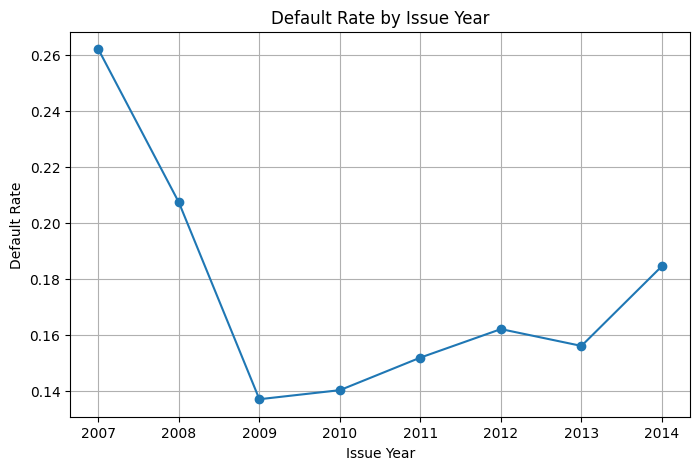

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(default_by_year["issue_year"], default_by_year["default_rate"], marker="o")
plt.title("Default Rate by Issue Year")
plt.xlabel("Issue Year")
plt.ylabel("Default Rate")
plt.grid(True)
plt.show()

In [ ]:
## Risk Summary

def risk_summary(data, group_col, target_col="target"):
    summary = (
        data.groupby(group_col, observed=True)
        .agg(
            loan_count=(target_col, "count"),
            default_count=(target_col, "sum"),
            default_rate=(target_col, "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_fico=("fico_score", "mean"),
            avg_dti=("dti", "mean"),
            avg_income=("annual_inc", "mean")
        )
        .reset_index()
    )

    summary["portfolio_share"] = summary["loan_count"] / len(data)

    return summary.sort_values("default_rate", ascending=False)

In [ ]:
def add_policy_bands(data):
    data = data.copy()

    data["fico_policy_band"] = pd.cut(
        data["fico_score"],
        bins=[-np.inf, 640, 660, 680, 700, 720, 760, np.inf],
        labels=["<640", "640-659", "660-679", "680-699", "700-719", "720-759", "760+"]
    )

    data["dti_policy_band"] = pd.cut(
        data["dti"],
        bins=[-np.inf, 5, 10, 15, 20, 25, 30, 35, np.inf],
        labels=["<5", "5-10", "10-15", "15-20", "20-25", "25-30", "30-35", "35+"]
    )

    data["loan_to_income_band"] = pd.cut(
        data["loan_to_income"],
        bins=[-np.inf, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, np.inf],
        labels=["<5%", "5-10%", "10-20%", "20-30%", "30-40%", "40-50%", "50%+"]
    )

    data["income_band"] = pd.cut(
        data["annual_inc"],
        bins=[-np.inf, 30000, 50000, 75000, 100000, 150000, np.inf],
        labels=["<30k", "30-50k", "50-75k", "75-100k", "100-150k", "150k+"]
    )

    if "revol_util_capped" in data.columns:
        data["revol_util_band"] = pd.cut(
            data["revol_util_capped"],
            bins=[-np.inf, 20, 40, 60, 80, np.inf],
            labels=["<20", "20-40", "40-60", "60-80", "80+"]
        )

    return data

In [ ]:
train_eda = add_policy_bands(train_model_v1)
valid_eda = add_policy_bands(valid_model_v1)
test_eda = add_policy_bands(test_model_v1)

In [ ]:
risk_summary(test_eda, "fico_policy_band")

,fico_policy_band,loan_count,default_count,default_rate,avg_loan_amount,avg_fico,avg_dti,avg_income,portfolio_share
0,660-679,84734,18938,0.2235,"12,795.6977",669.1069,17.6595,"68,032.1569",0.3798
1,680-699,61963,12141,0.1959,"14,813.1195",688.9087,18.4960,"73,867.2404",0.2777
2,700-719,38924,6140,0.1577,"16,261.5982",708.6925,18.6121,"79,625.7881",0.1745
3,720-759,28397,3297,0.1161,"16,858.8407",734.6158,17.6581,"84,508.1256",0.1273
4,760+,9085,646,0.0711,"15,375.5173",782.4856,14.7066,"87,182.2853",0.0407


In [ ]:
risk_summary(test_eda, "dti_policy_band")

,dti_policy_band,loan_count,default_count,default_rate,avg_loan_amount,avg_fico,avg_dti,avg_income,portfolio_share
7,35+,3229,978,0.3029,"13,316.4912",691.3187,37.2848,"52,536.6355",0.0145
6,30-35,13864,3523,0.2541,"14,058.4860",692.4858,32.2794,"56,633.6586",0.0621
5,25-30,28824,6643,0.2305,"14,636.9215",693.5362,27.3254,"61,201.2406",0.1292
4,20-25,40964,8435,0.2059,"15,006.6723",693.9188,22.3853,"66,809.3173",0.1836
3,15-20,50035,8938,0.1786,"15,014.1881",694.2317,17.4820,"73,779.9761",0.2243
2,10-15,47230,7295,0.1545,"14,715.9226",694.6567,12.5997,"81,761.8961",0.2117
1,5-10,29263,4124,0.1409,"13,996.5793",695.3773,7.7855,"90,158.3930",0.1312
0,<5,9694,1226,0.1265,"12,699.1876",700.9961,3.2776,"101,681.7923",0.0435


In [ ]:
risk_summary(test_eda, "loan_to_income_band")

,loan_to_income_band,loan_count,default_count,default_rate,avg_loan_amount,avg_fico,avg_dti,avg_income,portfolio_share
5,40-50%,13987,3863,0.2762,"22,184.1013",700.9644,21.4206,"50,584.1575",0.0627
4,30-40%,39045,10176,0.2606,"19,474.5537",693.6411,20.5103,"56,106.2514",0.1750
3,20-30%,61461,12226,0.1989,"16,793.0940",694.4387,18.7772,"67,674.5645",0.2755
2,10-20%,74472,10980,0.1474,"12,342.3579",694.0059,16.5112,"81,546.4926",0.3338
1,5-10%,26085,3094,0.1186,"7,626.0715",693.8383,15.1350,"97,601.9547",0.1169
0,<5%,8053,823,0.1022,"4,049.4257",693.7273,15.2756,"118,768.4202",0.0361


In [ ]:
## Drift summaries

def split_numeric_drift(train, valid, test, cols):
    rows = []

    for col in cols:
        for split_name, data in [
            ("Train", train),
            ("Validation", valid),
            ("Test", test)
        ]:
            s = pd.to_numeric(data[col], errors="coerce")

            rows.append({
                "feature": col,
                "split": split_name,
                "missing_rate": s.isna().mean(),
                "mean": s.mean(),
                "median": s.median(),
                "p25": s.quantile(0.25),
                "p75": s.quantile(0.75),
                "p95": s.quantile(0.95)
            })

    return pd.DataFrame(rows)

In [ ]:
numeric_drift_summary = split_numeric_drift(
    train_model_v1,
    valid_model_v1,
    test_model_v1,
    [
        "fico_score",
        "dti",
        "loan_to_income",
        "annual_inc",
        "loan_amnt",
        "revol_util_capped",
        "int_rate"
    ]
)

numeric_drift_summary

,feature,split,missing_rate,mean,median,p25,p75,p95
0,fico_score,Train,0.0000,708.5611,702.0000,682.0000,727.0000,777.0000
1,fico_score,Validation,0.0000,696.9989,692.0000,677.0000,712.0000,752.0000
2,fico_score,Test,0.0000,694.4679,687.0000,672.0000,707.0000,752.0000
3,dti,Train,0.0000,15.2029,15.0900,9.6600,20.5400,27.7800
4,dti,Validation,0.0000,17.2177,16.8900,11.4700,22.8000,30.1700
5,dti,Test,0.0000,17.9376,17.5100,11.9300,23.6500,31.8100
6,loan_to_income,Train,0.0000,0.2029,0.1846,0.1111,0.2778,0.4167
7,loan_to_income,Validation,0.0000,0.2230,0.2121,0.1391,0.3000,0.4372
8,loan_to_income,Test,0.0000,0.2192,0.2069,0.1333,0.2991,0.4183
9,annual_inc,Train,0.0000,"69,461.3711","60,000.0000","42,000.0000","83,954.0000","142,000.0000"


In [ ]:
def categorical_share_by_split(train, valid, test, col):
    rows = []

    for split_name, data in [
        ("Train", train),
        ("Validation", valid),
        ("Test", test)
    ]:
        temp = (
            data[col]
            .value_counts(normalize=True, dropna=False)
            .reset_index()
        )

        temp.columns = [col, "share"]
        temp["split"] = split_name
        rows.append(temp)

    return pd.concat(rows, ignore_index=True)

In [ ]:
purpose_drift = categorical_share_by_split(
    train_model_v1,
    valid_model_v1,
    test_model_v1,
    "purpose"
)

purpose_drift

,purpose,share,split
0,debt_consolidation,0.5275,Train
1,credit_card,0.1652,Train
2,other,0.0780,Train
3,home_improvement,0.0635,Train
4,major_purchase,0.0383,Train
5,small_business,0.0352,Train
6,car,0.0262,Train
7,wedding,0.0181,Train
8,medical,0.0144,Train
9,moving,0.0107,Train


In [ ]:
term_drift = categorical_share_by_split(
    train_model_v1,
    valid_model_v1,
    test_model_v1,
    "loan_term"
)

term_drift

,loan_term,share,split
0,36,0.7821,Train
1,60,0.2179,Train
2,36,0.7449,Validation
3,60,0.2551,Validation
4,36,0.7287,Test
5,60,0.2713,Test


# 5. PD Model Development and Model Selection

## 5.1 Define model inputs and preprocessing

In [ ]:
X_train = train_model_v1[final_features_v1].copy()
y_train = train_model_v1["target"].copy()

X_valid = valid_model_v1[final_features_v1].copy()
y_valid = valid_model_v1["target"].copy()

X_test = test_model_v1[final_features_v1].copy()
y_test = test_model_v1["target"].copy()

In [ ]:
def gini_from_auc(auc):
    return 2 * auc - 1


def ks_statistic(y_true, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    return np.max(tpr - fpr)


def evaluate_binary_model(y_true, y_pred_proba, model_name, dataset_name):
    auc = roc_auc_score(y_true, y_pred_proba)

    return {
        "model": model_name,
        "dataset": dataset_name,
        "loan_count": len(y_true),
        "actual_default_rate": y_true.mean(),
        "predicted_default_rate": np.mean(y_pred_proba),
        "auc": auc,
        "gini": gini_from_auc(auc),
        "ks": ks_statistic(y_true, y_pred_proba),
        "brier_score": brier_score_loss(y_true, y_pred_proba),
        "average_precision": average_precision_score(y_true, y_pred_proba)
    }


def create_decile_analysis(y_true, y_pred_proba, n_bins=10):
    temp = pd.DataFrame({
        "actual": y_true,
        "predicted_pd": y_pred_proba
    })

    temp["decile"] = pd.qcut(
        temp["predicted_pd"],
        q=n_bins,
        labels=False,
        duplicates="drop"
    ) + 1

    summary = (
        temp.groupby("decile")
        .agg(
            loan_count=("actual", "count"),
            actual_defaults=("actual", "sum"),
            actual_default_rate=("actual", "mean"),
            avg_predicted_pd=("predicted_pd", "mean"),
            min_predicted_pd=("predicted_pd", "min"),
            max_predicted_pd=("predicted_pd", "max")
        )
        .reset_index()
        .sort_values("decile")
    )

    summary["prediction_error"] = (
        summary["avg_predicted_pd"] - summary["actual_default_rate"]
    )

    return summary

In [ ]:
#Logistic model preprocessing pipelines
numeric_transformer_logit = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_logit = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, final_numeric_features_v1),
        ("cat", categorical_transformer_logit, final_categorical_features_v1)
    ]
)

In [ ]:
#Tree model preprocessing pipeline
numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, final_numeric_features_v1),
        ("cat", categorical_transformer_tree, final_categorical_features_v1)
    ]
)

## 5.2 Baseline logistic regression

In [ ]:
#Standard Log Regression, no class weights
logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logit),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            C=1.0
        ))
    ]
)

logit_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'loan_term',
                                                   'fico_score',
                                                   'dti_capped_40', 'log_dti',
                                                   'log_annual_inc',
                                                   'log_loan_to_income',
                                                   'log_installment_to_income',
                                                   'log_revol_bal',
                                                   'log_revol_bal_to_income',
                                                   'employment_leng...
                                                   'mths_since_recent_revol_delinq_no_event_flag',
                                                   'chargeoff_within_12_mths']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose', 'addr_state',
                                                   'application_type'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
#Predict
logit_train_pd = logit_model.predict_proba(X_train)[:, 1]
logit_valid_pd = logit_model.predict_proba(X_valid)[:, 1]
logit_test_pd = logit_model.predict_proba(X_test)[:, 1]

In [ ]:
logit_results = pd.DataFrame([
    evaluate_binary_model(y_train, logit_train_pd, "Logistic Regression", "Train"),
    evaluate_binary_model(y_valid, logit_valid_pd, "Logistic Regression", "Validation"),
    evaluate_binary_model(y_test, logit_test_pd, "Logistic Regression", "Test")
])

logit_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Logistic Regression,Train,95902,0.1572,0.1572,0.6972,0.3944,0.2863,0.1234,0.2969
1,Logistic Regression,Validation,134804,0.1560,0.1725,0.6733,0.3467,0.2546,0.1254,0.2669
2,Logistic Regression,Test,223103,0.1845,0.1769,0.6821,0.3642,0.2651,0.1409,0.3178


## 5.3 Class-weighted logistic regression

As comparison only

In [ ]:
logit_balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logit),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            C=1.0,
            class_weight="balanced"
        ))
    ]
)

logit_balanced_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'loan_term',
                                                   'fico_score',
                                                   'dti_capped_40', 'log_dti',
                                                   'log_annual_inc',
                                                   'log_loan_to_income',
                                                   'log_installment_to_income',
                                                   'log_revol_bal',
                                                   'log_revol_bal_to_income',
                                                   'employment_leng...
                                                   'mths_since_recent_revol_delinq_no_event_flag',
                                                   'chargeoff_within_12_mths']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose', 'addr_state',
                                                   'application_type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
logit_bal_train_pd = logit_balanced_model.predict_proba(X_train)[:, 1]
logit_bal_valid_pd = logit_balanced_model.predict_proba(X_valid)[:, 1]
logit_bal_test_pd = logit_balanced_model.predict_proba(X_test)[:, 1]

In [ ]:
logit_balanced_results = pd.DataFrame([
    evaluate_binary_model(y_train, logit_bal_train_pd, "Logistic Regression Balanced", "Train"),
    evaluate_binary_model(y_valid, logit_bal_valid_pd, "Logistic Regression Balanced", "Validation"),
    evaluate_binary_model(y_test, logit_bal_test_pd, "Logistic Regression Balanced", "Test")
])

logit_balanced_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Logistic Regression Balanced,Train,95902,0.1572,0.4592,0.6975,0.3950,0.2854,0.2208,0.2962
1,Logistic Regression Balanced,Validation,134804,0.1560,0.4900,0.6733,0.3467,0.2548,0.2436,0.2663
2,Logistic Regression Balanced,Test,223103,0.1845,0.4958,0.6819,0.3637,0.2643,0.2435,0.3171


## 5.4 Tuned logistic regression

In [ ]:
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

logit_tuning_rows = []

for C in C_values:
    temp_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor_logit),
            ("model", LogisticRegression(
                max_iter=1000,
                solver="lbfgs",
                C=C
            ))
        ]
    )

    temp_model.fit(X_train, y_train)

    train_pd = temp_model.predict_proba(X_train)[:, 1]
    valid_pd = temp_model.predict_proba(X_valid)[:, 1]

    train_eval = evaluate_binary_model(
        y_train,
        train_pd,
        f"Logistic C={C}",
        "Train"
    )

    valid_eval = evaluate_binary_model(
        y_valid,
        valid_pd,
        f"Logistic C={C}",
        "Validation"
    )

    train_eval["C"] = C
    valid_eval["C"] = C

    logit_tuning_rows.append(train_eval)
    logit_tuning_rows.append(valid_eval)

logit_tuning_results = pd.DataFrame(logit_tuning_rows)

logit_tuning_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision,C
0,Logistic C=0.01,Train,95902,0.1572,0.1572,0.6964,0.3929,0.2849,0.1235,0.2961,0.0100
1,Logistic C=0.01,Validation,134804,0.1560,0.1723,0.6735,0.3471,0.2541,0.1253,0.2674,0.0100
2,Logistic C=0.05,Train,95902,0.1572,0.1572,0.6971,0.3942,0.2857,0.1234,0.2968,0.0500
3,Logistic C=0.05,Validation,134804,0.1560,0.1722,0.6736,0.3471,0.2547,0.1254,0.2673,0.0500
4,Logistic C=0.1,Train,95902,0.1572,0.1572,0.6972,0.3943,0.2859,0.1234,0.2969,0.1000
5,Logistic C=0.1,Validation,134804,0.1560,0.1721,0.6734,0.3469,0.2544,0.1254,0.2672,0.1000
6,Logistic C=0.5,Train,95902,0.1572,0.1572,0.6972,0.3944,0.2858,0.1234,0.2969,0.5000
7,Logistic C=0.5,Validation,134804,0.1560,0.1722,0.6734,0.3467,0.2546,0.1254,0.2671,0.5000
8,Logistic C=1.0,Train,95902,0.1572,0.1572,0.6972,0.3944,0.2863,0.1234,0.2969,1.0000
9,Logistic C=1.0,Validation,134804,0.1560,0.1725,0.6733,0.3467,0.2546,0.1254,0.2669,1.0000


In [ ]:
logit_valid_tuning = (
    logit_tuning_results[logit_tuning_results["dataset"] == "Validation"]
    .sort_values(["auc", "brier_score"], ascending=[False, True])
)

logit_valid_tuning

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision,C
3,Logistic C=0.05,Validation,134804,0.1560,0.1722,0.6736,0.3471,0.2547,0.1254,0.2673,0.0500
1,Logistic C=0.01,Validation,134804,0.1560,0.1723,0.6735,0.3471,0.2541,0.1253,0.2674,0.0100
5,Logistic C=0.1,Validation,134804,0.1560,0.1721,0.6734,0.3469,0.2544,0.1254,0.2672,0.1000
7,Logistic C=0.5,Validation,134804,0.1560,0.1722,0.6734,0.3467,0.2546,0.1254,0.2671,0.5000
9,Logistic C=1.0,Validation,134804,0.1560,0.1725,0.6733,0.3467,0.2546,0.1254,0.2669,1.0000
11,Logistic C=2.0,Validation,134804,0.1560,0.1725,0.6733,0.3465,0.2542,0.1255,0.2667,2.0000
13,Logistic C=5.0,Validation,134804,0.1560,0.1724,0.6732,0.3465,0.2541,0.1255,0.2668,5.0000


In [ ]:
best_C = logit_valid_tuning.iloc[0]["C"]
best_C

np.float64(0.05)

In [ ]:
## Fit final tuned logistic model
best_logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logit),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="lbfgs",
            C=best_C
        ))
    ]
)

best_logit_model.fit(X_train, y_train)

best_logit_train_pd = best_logit_model.predict_proba(X_train)[:, 1]
best_logit_valid_pd = best_logit_model.predict_proba(X_valid)[:, 1]
best_logit_test_pd = best_logit_model.predict_proba(X_test)[:, 1]

In [ ]:
best_logit_results = pd.DataFrame([
    evaluate_binary_model(y_train, best_logit_train_pd, "Best Logistic Regression", "Train"),
    evaluate_binary_model(y_valid, best_logit_valid_pd, "Best Logistic Regression", "Validation"),
    evaluate_binary_model(y_test, best_logit_test_pd, "Best Logistic Regression", "Test")
])

best_logit_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Best Logistic Regression,Train,95902,0.1572,0.1572,0.6971,0.3942,0.2857,0.1234,0.2968
1,Best Logistic Regression,Validation,134804,0.1560,0.1722,0.6736,0.3471,0.2547,0.1254,0.2673
2,Best Logistic Regression,Test,223103,0.1845,0.1764,0.6826,0.3651,0.2662,0.1408,0.3183


## 5.5 Gradient boosting challenger

In [ ]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['loan_amnt', 'loan_term',
                                                   'fico_score',
                                                   'dti_capped_40', 'log_dti',
                                                   'log_annual_inc',
                                                   'log_loan_to_income',
                                                   'log_installment_to_income',
                                                   'log_revol_bal',
                                                   'log_revol_bal_to_income',
                                                   'employment_length_in_years',
                                                   'log_credit_his...
                                                   'chargeoff_within_12_mths']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['home_ownership',
                                                   'verification_status',
                                                   'purpose', 'addr_state',
                                                   'application_type'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=250,
                                            random_state=42))])

In [ ]:
gb_train_pd = gb_model.predict_proba(X_train)[:, 1]
gb_valid_pd = gb_model.predict_proba(X_valid)[:, 1]
gb_test_pd = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
gb_results = pd.DataFrame([
    evaluate_binary_model(y_train, gb_train_pd, "Gradient Boosting", "Train"),
    evaluate_binary_model(y_valid, gb_valid_pd, "Gradient Boosting", "Validation"),
    evaluate_binary_model(y_test, gb_test_pd, "Gradient Boosting", "Test")
])

gb_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Gradient Boosting,Train,95902,0.1572,0.1572,0.7115,0.4229,0.3068,0.1217,0.3225
1,Gradient Boosting,Validation,134804,0.1560,0.1731,0.6752,0.3504,0.2510,0.1252,0.2676
2,Gradient Boosting,Test,223103,0.1845,0.1794,0.6856,0.3712,0.2702,0.1406,0.3184


## 5.6 Model performance comparison

In [ ]:
#Combine Model performance

model_performance_v1 = pd.concat(
    [
        logit_results,
        logit_balanced_results,
        best_logit_results,
        gb_results
    ],
    ignore_index=True
)

model_performance_v1

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Logistic Regression,Train,95902,0.1572,0.1572,0.6972,0.3944,0.2863,0.1234,0.2969
1,Logistic Regression,Validation,134804,0.1560,0.1725,0.6733,0.3467,0.2546,0.1254,0.2669
2,Logistic Regression,Test,223103,0.1845,0.1769,0.6821,0.3642,0.2651,0.1409,0.3178
3,Logistic Regression Balanced,Train,95902,0.1572,0.4592,0.6975,0.3950,0.2854,0.2208,0.2962
4,Logistic Regression Balanced,Validation,134804,0.1560,0.4900,0.6733,0.3467,0.2548,0.2436,0.2663
5,Logistic Regression Balanced,Test,223103,0.1845,0.4958,0.6819,0.3637,0.2643,0.2435,0.3171
6,Best Logistic Regression,Train,95902,0.1572,0.1572,0.6971,0.3942,0.2857,0.1234,0.2968
7,Best Logistic Regression,Validation,134804,0.1560,0.1722,0.6736,0.3471,0.2547,0.1254,0.2673
8,Best Logistic Regression,Test,223103,0.1845,0.1764,0.6826,0.3651,0.2662,0.1408,0.3183
9,Gradient Boosting,Train,95902,0.1572,0.1572,0.7115,0.4229,0.3068,0.1217,0.3225


In [ ]:
test_model_performance_v1 = (
    model_performance_v1[model_performance_v1["dataset"] == "Test"]
    .sort_values("auc", ascending=False)
)

test_model_performance_v1

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
11,Gradient Boosting,Test,223103,0.1845,0.1794,0.6856,0.3712,0.2702,0.1406,0.3184
8,Best Logistic Regression,Test,223103,0.1845,0.1764,0.6826,0.3651,0.2662,0.1408,0.3183
2,Logistic Regression,Test,223103,0.1845,0.1769,0.6821,0.3642,0.2651,0.1409,0.3178
5,Logistic Regression Balanced,Test,223103,0.1845,0.4958,0.6819,0.3637,0.2643,0.2435,0.3171


In [ ]:
## Compare decile performance

# Best logistic decile analysis

best_logit_valid_deciles = create_decile_analysis(
    y_valid,
    best_logit_valid_pd
)

best_logit_test_deciles = create_decile_analysis(
    y_test,
    best_logit_test_pd
)

best_logit_test_deciles

,decile,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,prediction_error
0,1,22311,1295,0.0580,0.0486,0.0000,0.0677,-0.0095
1,2,22310,1921,0.0861,0.0804,0.0677,0.0919,-0.0057
2,3,22310,2325,0.1042,0.1025,0.0919,0.1129,-0.0017
3,4,22310,2941,0.1318,0.1232,0.1130,0.1335,-0.0086
4,5,22311,3403,0.1525,0.1444,0.1335,0.1556,-0.0081
5,6,22310,3909,0.1752,0.1681,0.1556,0.1812,-0.0071
6,7,22310,4514,0.2023,0.1962,0.1812,0.2127,-0.0062
7,8,22310,5443,0.2440,0.2324,0.2127,0.2544,-0.0115
8,9,22310,6743,0.3022,0.2836,0.2544,0.3178,-0.0187
9,10,22311,8668,0.3885,0.3852,0.3178,0.7712,-0.0033


In [ ]:
# Gradient boosting decile analysis

gb_valid_deciles = create_decile_analysis(
    y_valid,
    gb_valid_pd
)

gb_test_deciles = create_decile_analysis(
    y_test,
    gb_test_pd
)

gb_test_deciles

,decile,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,prediction_error
0,1,22311,1078,0.0483,0.0596,0.0193,0.0776,0.0112
1,2,22310,1863,0.0835,0.0889,0.0776,0.0993,0.0054
2,3,22310,2470,0.1107,0.1091,0.0993,0.1188,-0.0016
3,4,22310,2897,0.1299,0.1286,0.1188,0.1385,-0.0013
4,5,22311,3524,0.1579,0.1488,0.1385,0.1596,-0.0091
5,6,22310,3829,0.1716,0.1713,0.1596,0.1835,-0.0004
6,7,22310,4606,0.2065,0.1975,0.1835,0.2126,-0.0089
7,8,22310,5486,0.2459,0.2310,0.2126,0.2512,-0.0149
8,9,22310,6679,0.2994,0.2786,0.2512,0.3118,-0.0208
9,10,22311,8730,0.3913,0.3809,0.3119,0.8294,-0.0104


In [ ]:
#Plot ROC Curve

gb_valid_deciles = create_decile_analysis(
    y_valid,
    gb_valid_pd
)

gb_test_deciles = create_decile_analysis(
    y_test,
    gb_test_pd
)

gb_test_deciles

,decile,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,prediction_error
0,1,22311,1078,0.0483,0.0596,0.0193,0.0776,0.0112
1,2,22310,1863,0.0835,0.0889,0.0776,0.0993,0.0054
2,3,22310,2470,0.1107,0.1091,0.0993,0.1188,-0.0016
3,4,22310,2897,0.1299,0.1286,0.1188,0.1385,-0.0013
4,5,22311,3524,0.1579,0.1488,0.1385,0.1596,-0.0091
5,6,22310,3829,0.1716,0.1713,0.1596,0.1835,-0.0004
6,7,22310,4606,0.2065,0.1975,0.1835,0.2126,-0.0089
7,8,22310,5486,0.2459,0.2310,0.2126,0.2512,-0.0149
8,9,22310,6679,0.2994,0.2786,0.2512,0.3118,-0.0208
9,10,22311,8730,0.3913,0.3809,0.3119,0.8294,-0.0104


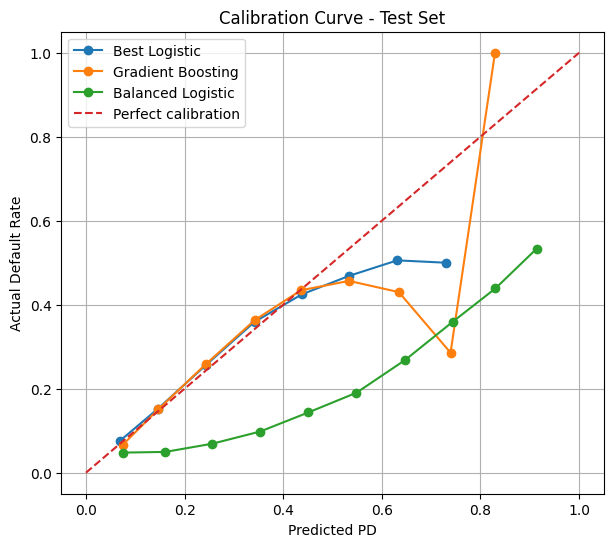

In [ ]:
#Plot Calibration Curve

plt.figure(figsize=(7, 6))

for model_name, preds in [
    ("Best Logistic", best_logit_test_pd),
    ("Gradient Boosting", gb_test_pd),
    ("Balanced Logistic", logit_bal_test_pd)
]:
    prob_true, prob_pred = calibration_curve(
        y_test,
        preds,
        n_bins=10
    )

    plt.plot(prob_pred, prob_true, marker="o", label=model_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curve - Test Set")
plt.xlabel("Predicted PD")
plt.ylabel("Actual Default Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create calibration tables

calibration_tables = {
    "best_logit_test_deciles": best_logit_test_deciles,
    "gb_test_deciles": gb_test_deciles
}

calibration_tables


{'best_logit_test_deciles':    decile  loan_count  actual_defaults  actual_default_rate  avg_predicted_pd  \
 0       1       22311             1295               0.0580            0.0486   
 1       2       22310             1921               0.0861            0.0804   
 2       3       22310             2325               0.1042            0.1025   
 3       4       22310             2941               0.1318            0.1232   
 4       5       22311             3403               0.1525            0.1444   
 5       6       22310             3909               0.1752            0.1681   
 6       7       22310             4514               0.2023            0.1962   
 7       8       22310             5443               0.2440            0.2324   
 8       9       22310             6743               0.3022            0.2836   
 9      10       22311             8668               0.3885            0.3852   
 
    min_predicted_pd  max_predicted_pd  prediction_error  
 0        

In [ ]:
#Create PD output datasets

pd_train_output = train_model_v1.copy()
pd_valid_output = valid_model_v1.copy()
pd_test_output = test_model_v1.copy()

pd_train_output["final_pd_uncalibrated"] = best_logit_train_pd
pd_valid_output["final_pd_uncalibrated"] = best_logit_valid_pd
pd_test_output["final_pd_uncalibrated"] = best_logit_test_pd

## 5.7 Final model selection

Recommended Model decision for now



Primary model: Best Logistic Regression
Challenger model: Gradient Boosting
Reject final PD use: Balanced Logistic Regression

Why?

Because the logistic model:

- Has nearly the same AUC as Gradient Boosting.
- Has good predicted default-rate alignment.
- Is easier to explain.
- Is more defensible for policy, pricing, and limits.
- Can be converted into a scorecard-style framework later.

However, before finalizing, we should do proper calibration.

# 6. Calibration, Final PD Selection, and Risk Banding

## 6.1 Calibration methods tested

In [ ]:
def logit_transform(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def inverse_logit(x):
    return 1 / (1 + np.exp(-x))


def calibration_decile_table(data, pd_col, target_col="target", n_bins=10):
    temp = data[[pd_col, target_col]].copy()

    temp["decile"] = pd.qcut(
        temp[pd_col],
        q=n_bins,
        labels=False,
        duplicates="drop"
    ) + 1

    summary = (
        temp.groupby("decile")
        .agg(
            loan_count=(target_col, "count"),
            actual_defaults=(target_col, "sum"),
            actual_default_rate=(target_col, "mean"),
            avg_predicted_pd=(pd_col, "mean"),
            min_predicted_pd=(pd_col, "min"),
            max_predicted_pd=(pd_col, "max")
        )
        .reset_index()
    )

    summary["prediction_error"] = (
        summary["avg_predicted_pd"] - summary["actual_default_rate"]
    )

    return summary

### 6.1.1 Simple validation-rate calibration

In [ ]:
#Calibration method 1: Simple validation-rate calibration

valid_actual_rate = y_valid.mean()
valid_pred_rate = best_logit_valid_pd.mean()

simple_calibration_factor = valid_actual_rate / valid_pred_rate

pd_test_output["pd_simple_calibrated"] = np.clip(
    pd_test_output["final_pd_uncalibrated"] * simple_calibration_factor,
    1e-6,
    1 - 1e-6
)

### 6.1.2 Intercept calibration

In [ ]:
## Calibration Method 2: Intercept calibration

valid_logit_pd = logit_transform(best_logit_valid_pd)

intercept_shift = logit_transform(valid_actual_rate) - logit_transform(valid_pred_rate)

pd_test_output["pd_intercept_calibrated_validation"] = inverse_logit(
    logit_transform(pd_test_output["final_pd_uncalibrated"]) + intercept_shift
)


### 6.1.3 Logistic recalibration

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

## Calibration Method 3: Logistic recalibration

logistic_recalibrator = SklearnLogisticRegression(
    max_iter=1000,
    solver="lbfgs"
)

logistic_recalibrator.fit(
    valid_logit_pd.reshape(-1, 1),
    y_valid
)

pd_test_output["pd_logistic_recalibrated"] = logistic_recalibrator.predict_proba(
    logit_transform(pd_test_output["final_pd_uncalibrated"]).values.reshape(-1, 1)
)[:, 1]

### 6.1.4 Isotonic calibration

In [ ]:
## Method 4: Isotonic calibration

isotonic_recalibrator = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_recalibrator.fit(
    best_logit_valid_pd,
    y_valid
)

pd_test_output["pd_isotonic_calibrated"] = isotonic_recalibrator.predict(
    pd_test_output["final_pd_uncalibrated"]
)

## 6.2 Calibration comparison


In [ ]:
#Compare calibration method

calibration_results = pd.DataFrame([
    evaluate_binary_model(
        y_test,
        pd_test_output["final_pd_uncalibrated"],
        "Best Logistic - Uncalibrated",
        "Test"
    ),
    evaluate_binary_model(
        y_test,
        pd_test_output["pd_simple_calibrated"],
        "Best Logistic - Simple Calibrated",
        "Test"
    ),
    evaluate_binary_model(
        y_test,
        pd_test_output["pd_intercept_calibrated_validation"],
        "Best Logistic - Intercept Calibrated on Validation",
        "Test"
    ),
    evaluate_binary_model(
        y_test,
        pd_test_output["pd_logistic_recalibrated"],
        "Best Logistic - Logistic Recalibrated",
        "Test"
    ),
    evaluate_binary_model(
        y_test,
        pd_test_output["pd_isotonic_calibrated"],
        "Best Logistic - Isotonic Calibrated",
        "Test"
    )
])

calibration_results

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Best Logistic - Uncalibrated,Test,223103,0.1845,0.1764,0.6826,0.3651,0.2662,0.1408,0.3183
1,Best Logistic - Simple Calibrated,Test,223103,0.1845,0.1598,0.6826,0.3651,0.2662,0.1414,0.3183
2,Best Logistic - Intercept Calibrated on Valida...,Test,223103,0.1845,0.1609,0.6826,0.3651,0.2662,0.1413,0.3183
3,Best Logistic - Logistic Recalibrated,Test,223103,0.1845,0.1596,0.6826,0.3651,0.2662,0.1415,0.3183
4,Best Logistic - Isotonic Calibrated,Test,223103,0.1845,0.1596,0.6824,0.3648,0.2655,0.1415,0.3139


In [ ]:
uncalibrated_deciles = calibration_decile_table(
    pd_test_output,
    "final_pd_uncalibrated",
    target_col="target"
)

uncalibrated_deciles

,decile,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,prediction_error
0,1,22311,1295,0.0580,0.0486,0.0000,0.0677,-0.0095
1,2,22310,1921,0.0861,0.0804,0.0677,0.0919,-0.0057
2,3,22310,2325,0.1042,0.1025,0.0919,0.1129,-0.0017
3,4,22310,2941,0.1318,0.1232,0.1130,0.1335,-0.0086
4,5,22311,3403,0.1525,0.1444,0.1335,0.1556,-0.0081
5,6,22310,3909,0.1752,0.1681,0.1556,0.1812,-0.0071
6,7,22310,4514,0.2023,0.1962,0.1812,0.2127,-0.0062
7,8,22310,5443,0.2440,0.2324,0.2127,0.2544,-0.0115
8,9,22310,6743,0.3022,0.2836,0.2544,0.3178,-0.0187
9,10,22311,8668,0.3885,0.3852,0.3178,0.7712,-0.0033


In [ ]:
logistic_recalibrated_deciles = calibration_decile_table(
    pd_test_output,
    "pd_logistic_recalibrated",
    target_col="target"
)

logistic_recalibrated_deciles

,decile,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,prediction_error
0,1,22311,1295,0.0580,0.0476,0.0000,0.0651,-0.0105
1,2,22310,1921,0.0861,0.0763,0.0651,0.0865,-0.0098
2,3,22310,2325,0.1042,0.0958,0.0865,0.1050,-0.0084
3,4,22310,2941,0.1318,0.1139,0.1050,0.1228,-0.0179
4,5,22311,3403,0.1525,0.1323,0.1228,0.1419,-0.0203
5,6,22310,3909,0.1752,0.1526,0.1419,0.1639,-0.0226
6,7,22310,4514,0.2023,0.1768,0.1639,0.1910,-0.0255
7,8,22310,5443,0.2440,0.2079,0.1910,0.2268,-0.0360
8,9,22310,6743,0.3022,0.2520,0.2268,0.2816,-0.0503
9,10,22311,8668,0.3885,0.3410,0.2816,0.7119,-0.0475


In [ ]:
## final PD decision

pd_train_output["final_pd"] = pd_train_output["final_pd_uncalibrated"]
pd_valid_output["final_pd"] = pd_valid_output["final_pd_uncalibrated"]
pd_test_output["final_pd"] = pd_test_output["final_pd_uncalibrated"]

final_pd_summary = pd.DataFrame({
    "metric": [
        "model_name",
        "loan_count",
        "actual_default_rate",
        "predicted_default_rate",
        "auc",
        "gini",
        "ks",
        "brier_score"
    ],
    "value": [
        "Best Logistic Regression - Uncalibrated",
        len(pd_test_output),
        y_test.mean(),
        pd_test_output["final_pd"].mean(),
        roc_auc_score(y_test, pd_test_output["final_pd"]),
        gini_from_auc(roc_auc_score(y_test, pd_test_output["final_pd"])),
        ks_statistic(y_test, pd_test_output["final_pd"]),
        brier_score_loss(y_test, pd_test_output["final_pd"])
    ]
})

final_pd_summary

,metric,value
0,model_name,Best Logistic Regression - Uncalibrated
1,loan_count,223103
2,actual_default_rate,0.1845
3,predicted_default_rate,0.1764
4,auc,0.6826
5,gini,0.3651
6,ks,0.2662
7,brier_score,0.1408


The uncalibrated tuned logistic regression is retained as the final PD model. Validation-based recalibration reduced the average predicted default rate on the 2014 test set and worsened decile-level calibration. The uncalibrated model produced the most defensible balance of discrimination, calibration, and policy usability.


The calibration methods trained on validation made the test-period calibration worse because 2013 and 2014 behave differently.



Validation-based recalibration reduced predicted PDs because the 2013 validation vintage had a lower observed default rate than the 2014 test vintage. As a result, recalibrated PDs underpredicted 2014 risk more severely. The uncalibrated logistic model was therefore retained as the final PD estimate, with conservative stress overlays to be tested separately during profitability and policy analysis.

## 6.4 Business PD band definition

In [ ]:
business_pd_edges = [
    -np.inf,
    0.07,
    0.12,
    0.18,
    0.28,
    np.inf
]

business_pd_labels = [
    "A: Very Low Risk",
    "B: Low Risk",
    "C: Medium Risk",
    "D: High Risk",
    "E: Very High Risk"
]

In [ ]:
for data in [pd_train_output, pd_valid_output, pd_test_output]:
    data["final_pd_band"] = pd.cut(
        data["final_pd"],
        bins=business_pd_edges,
        labels=business_pd_labels
    )

In [ ]:
##Validate PD bands
def summarize_pd_bands(data, band_col="final_pd_band", target_col="target"):
    summary = (
        data.groupby(band_col, observed=True)
        .agg(
            loan_count=(target_col, "count"),
            actual_defaults=(target_col, "sum"),
            actual_default_rate=(target_col, "mean"),
            avg_predicted_pd=("final_pd", "mean"),
            min_predicted_pd=("final_pd", "min"),
            max_predicted_pd=("final_pd", "max"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_fico=("fico_score", "mean"),
            avg_dti=("dti", "mean"),
            avg_interest_rate=("int_rate", "mean")
        )
        .reset_index()
    )

    summary["population_share"] = summary["loan_count"] / len(data)
    summary["prediction_error"] = (
        summary["avg_predicted_pd"] - summary["actual_default_rate"]
    )

    return summary

In [ ]:
valid_pd_band_summary = summarize_pd_bands(pd_valid_output)
test_pd_band_summary = summarize_pd_bands(pd_test_output)

test_pd_band_summary

,final_pd_band,loan_count,actual_defaults,actual_default_rate,avg_predicted_pd,min_predicted_pd,max_predicted_pd,avg_loan_amount,avg_fico,avg_dti,avg_interest_rate,population_share,prediction_error
0,A: Very Low Risk,24098,1420,0.0589,0.0501,0.0000,0.0700,"13,590.1382",735.7074,14.0453,9.0066,0.1080,-0.0089
1,B: Low Risk,50452,5071,0.1005,0.0960,0.0700,0.1200,"13,272.4659",702.4790,16.2346,11.2657,0.2261,-0.0045
2,C: Medium Risk,58349,9135,0.1566,0.1484,0.1200,0.1800,"13,538.8387",689.1754,17.9123,13.3245,0.2615,-0.0081
3,D: High Risk,55937,13086,0.2339,0.2234,0.1800,0.2800,"15,378.1754",684.6648,19.3363,15.3538,0.2507,-0.0105
4,E: Very High Risk,34267,12450,0.3633,0.3548,0.2800,0.7712,"17,690.0575",678.6860,20.9420,18.2399,0.1536,-0.0085


# Approval Cut-off and Risk Appetite Analysis

In [ ]:
#create cut off analysis dataframe

cutoff_df = pd_test_output.copy()

In [ ]:
## Youden J threshold
fpr, tpr, thresholds = roc_curve(
    cutoff_df["target"],
    cutoff_df["final_pd"]
)

youden_j = tpr - fpr
best_index = np.argmax(youden_j)

youden_threshold = thresholds[best_index]

youden_summary = pd.DataFrame({
    "metric": [
        "youden_pd_threshold",
        "true_positive_rate_sensitivity",
        "false_positive_rate",
        "specificity",
        "youden_j"
    ],
    "value": [
        youden_threshold,
        tpr[best_index],
        fpr[best_index],
        1 - fpr[best_index],
        youden_j[best_index]
    ]
})

youden_summary


,metric,value
0,youden_pd_threshold,0.1754
1,true_positive_rate_sensitivity,0.6385
2,false_positive_rate,0.3723
3,specificity,0.6277
4,youden_j,0.2662


In [ ]:
pd_cutoffs = [
    0.07,
    0.10,
    0.12,
    0.15,
    0.18,
    0.20,
    0.25,
    0.28,
    0.30,
    0.35
]

cutoff_rows = []

for cutoff in pd_cutoffs:
    approved = cutoff_df[cutoff_df["final_pd"] <= cutoff].copy()
    declined = cutoff_df[cutoff_df["final_pd"] > cutoff].copy()

    cutoff_rows.append({
        "pd_cutoff": cutoff,
        "approved_count": len(approved),
        "approval_rate": len(approved) / len(cutoff_df),
        "declined_count": len(declined),
        "decline_rate": len(declined) / len(cutoff_df),
        "approved_actual_default_rate": approved["target"].mean(),
        "approved_avg_predicted_pd": approved["final_pd"].mean(),
        "approved_total_loan_amount": approved["loan_amnt"].sum(),
        "approved_avg_loan_amount": approved["loan_amnt"].mean()
    })

pd_cutoff_summary = pd.DataFrame(cutoff_rows)

pd_cutoff_summary

,pd_cutoff,approved_count,approval_rate,declined_count,decline_rate,approved_actual_default_rate,approved_avg_predicted_pd,approved_total_loan_amount,approved_avg_loan_amount
0,0.0700,24098,0.1080,199005,0.8920,0.0589,0.0501,"327,495,150.0000","13,590.1382"
1,0.1000,53171,0.2383,169932,0.7617,0.0766,0.0695,"714,788,100.0000","13,443.1946"
2,0.1200,74550,0.3342,148553,0.6658,0.0871,0.0811,"997,117,600.0000","13,375.1522"
3,0.1500,106039,0.4753,117064,0.5247,0.1035,0.0971,"1,416,914,300.0000","13,362.1998"
4,0.1800,132899,0.5957,90204,0.4043,0.1176,0.1107,"1,787,095,300.0000","13,447.0184"
5,0.2000,147916,0.6630,75187,0.3370,0.1253,0.1187,"2,004,487,725.0000","13,551.5274"
6,0.2500,176488,0.7911,46615,0.2089,0.1429,0.1357,"2,443,069,775.0000","13,842.6962"
7,0.2800,188836,0.8464,34267,0.1536,0.1520,0.1441,"2,647,304,300.0000","14,019.0658"
8,0.3000,195541,0.8765,27562,0.1235,0.1572,0.1491,"2,762,327,525.0000","14,126.5899"
9,0.3500,208264,0.9335,14839,0.0665,0.1685,0.1597,"2,986,255,900.0000","14,338.8003"


#7. WOE / IV Scorecard

This section develops an interpretable application scorecard using WOE/IV binning and logistic regression. Variables are binned using the training sample only to avoid data leakage. information Value is used for feature screening, while final variables are selected based on IV strength, monotonicity, business interpretability, sign consistency and avoidance of duplicate risk drivers

In [ ]:
# Define scorecard datasets
# Using the same train, validation, and test samples from the final PD modelling process.

scorecard_train = pd_train_output.copy()
scorecard_valid = pd_valid_output.copy()
scorecard_test = pd_test_output.copy()

target_col = "target"

y_score_train = scorecard_train[target_col].copy()
y_score_valid = scorecard_valid[target_col].copy()
y_score_test = scorecard_test[target_col].copy()

In [ ]:
scorecard_numeric_candidates = [
    "fico_score",
    "dti_capped_40",
    "log_annual_inc",
    "log_loan_to_income",
    "log_installment_to_income",
    "log_revol_bal",
    "log_revol_bal_to_income",
    "revol_util_capped",
    "inq_last_6mths",
    "delinq_2yrs",
    "open_acc_capped",
    "total_acc_capped",
    "pub_rec",
    "pub_rec_bankruptcies",
    "tax_liens",
    "loan_amnt",
    "loan_term"
]

scorecard_categorical_candidates = [
    "home_ownership",
    "verification_status",
    "purpose",
    "application_type"
]

scorecard_numeric_candidates = [
    col for col in scorecard_numeric_candidates
    if col in scorecard_train.columns
]

scorecard_categorical_candidates = [
    col for col in scorecard_categorical_candidates
    if col in scorecard_train.columns
]

scorecard_candidate_features = (
    scorecard_numeric_candidates + scorecard_categorical_candidates
)

scorecard_candidate_features

['fico_score',
 'dti_capped_40',
 'log_annual_inc',
 'log_loan_to_income',
 'log_installment_to_income',
 'log_revol_bal',
 'log_revol_bal_to_income',
 'revol_util_capped',
 'inq_last_6mths',
 'delinq_2yrs',
 'open_acc_capped',
 'total_acc_capped',
 'pub_rec',
 'pub_rec_bankruptcies',
 'tax_liens',
 'loan_amnt',
 'loan_term',
 'home_ownership',
 'verification_status',
 'purpose',
 'application_type']

In [ ]:
# Helper functions

def calculate_woe_iv_from_binned(data, bin_col, target_col):
    temp = data[[bin_col, target_col]].copy()
    temp[bin_col] = temp[bin_col].astype(str).fillna("Missing")

    grouped = (
        temp.groupby(bin_col, observed=True)
        .agg(
            total=(target_col, "count"),
            bad=(target_col, "sum")
        )
        .reset_index()
    )

    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    grouped["good_dist"] = (
        grouped["good"] + 0.5
    ) / (
        total_good + 0.5 * len(grouped)
    )

    grouped["bad_dist"] = (
        grouped["bad"] + 0.5
    ) / (
        total_bad + 0.5 * len(grouped)
    )

    grouped["woe"] = np.log(grouped["good_dist"] / grouped["bad_dist"])

    grouped["iv_component"] = (
        grouped["good_dist"] - grouped["bad_dist"]
    ) * grouped["woe"]

    grouped["bad_rate"] = grouped["bad"] / grouped["total"]
    grouped["population_share"] = grouped["total"] / grouped["total"].sum()
    grouped["iv"] = grouped["iv_component"].sum()

    return grouped.reset_index(drop=True)


def create_numeric_bins(train_series, max_bins=5):
    s = pd.to_numeric(train_series, errors="coerce")
    non_missing = s.dropna()

    if non_missing.nunique() <= 2:
        return None

    try:
        _, bin_edges = pd.qcut(
            non_missing,
            q=max_bins,
            retbins=True,
            duplicates="drop"
        )

        bin_edges[0] = -np.inf
        bin_edges[-1] = np.inf

        return bin_edges

    except Exception:
        return None


def apply_numeric_bins(data, numeric_bin_edges):
    data = data.copy()

    for col, edges in numeric_bin_edges.items():
        binned_col = f"{col}_bin"

        if edges is None:
            data[binned_col] = data[col].astype(str).fillna("Missing")
        else:
            data[binned_col] = pd.cut(
                pd.to_numeric(data[col], errors="coerce"),
                bins=edges,
                include_lowest=True
            ).astype(str)

            data.loc[data[col].isna(), binned_col] = "Missing"

    return data


def create_categorical_mapping(train_series, min_share=0.01):
    s = train_series.astype(str).fillna("Missing")
    shares = s.value_counts(normalize=True, dropna=False)

    common_categories = shares[shares >= min_share].index.tolist()

    return common_categories


def apply_categorical_bins(data, categorical_common_levels):
    data = data.copy()

    for col, common_levels in categorical_common_levels.items():
        binned_col = f"{col}_bin"

        raw = data[col].astype(str).fillna("Missing")

        data[binned_col] = np.where(
            raw.isin(common_levels),
            raw,
            "Other"
        )

    return data


def check_bad_rate_monotonicity(woe_table):
    temp = woe_table.copy()

    bin_col = temp.columns[0]
    temp = temp[
        ~temp[bin_col].astype(str).str.contains("Missing", na=False)
    ]

    bad_rates = temp["bad_rate"].values

    if len(bad_rates) <= 2:
        return "Too few bins"

    increasing = np.all(np.diff(bad_rates) >= 0)
    decreasing = np.all(np.diff(bad_rates) <= 0)

    if increasing:
        return "Monotonic increasing"
    elif decreasing:
        return "Monotonic decreasing"
    else:
        return "Non-monotonic"

In [ ]:
## train only binning

numeric_bin_edges = {}

for col in scorecard_numeric_candidates:
    numeric_bin_edges[col] = create_numeric_bins(
        scorecard_train[col],
        max_bins=5
    )

scorecard_train_binned = apply_numeric_bins(
    scorecard_train,
    numeric_bin_edges
)

scorecard_valid_binned = apply_numeric_bins(
    scorecard_valid,
    numeric_bin_edges
)

scorecard_test_binned = apply_numeric_bins(
    scorecard_test,
    numeric_bin_edges
)

In [ ]:
categorical_common_levels = {}

for col in scorecard_categorical_candidates:
    categorical_common_levels[col] = create_categorical_mapping(
        scorecard_train[col],
        min_share=0.01
    )

scorecard_train_binned = apply_categorical_bins(
    scorecard_train_binned,
    categorical_common_levels
)

scorecard_valid_binned = apply_categorical_bins(
    scorecard_valid_binned,
    categorical_common_levels
)

scorecard_test_binned = apply_categorical_bins(
    scorecard_test_binned,
    categorical_common_levels
)

In [ ]:
# Generate IV summary for all candidate variables


scorecard_binned_features = [
    f"{col}_bin" for col in scorecard_numeric_candidates
] + [
    f"{col}_bin" for col in scorecard_categorical_candidates
]

woe_tables = {}
iv_summary_rows = []

for binned_col in scorecard_binned_features:
    woe_table = calculate_woe_iv_from_binned(
        scorecard_train_binned,
        binned_col,
        target_col
    )

    original_feature = binned_col.replace("_bin", "")

    woe_table["feature"] = original_feature
    woe_table["bin_col"] = binned_col

    woe_tables[original_feature] = woe_table

    iv_summary_rows.append({
        "feature": original_feature,
        "bin_col": binned_col,
        "iv": woe_table["iv"].iloc[0],
        "bin_count": woe_table.shape[0],
        "min_bin_share": woe_table["population_share"].min(),
        "max_bin_bad_rate": woe_table["bad_rate"].max(),
        "min_bin_bad_rate": woe_table["bad_rate"].min()
    })

iv_summary = pd.DataFrame(iv_summary_rows).sort_values(
    "iv",
    ascending=False
)

iv_summary

,feature,bin_col,iv,bin_count,min_bin_share,max_bin_bad_rate,min_bin_bad_rate
0,fico_score,fico_score_bin,0.1379,5,0.1842,0.2245,0.0842
16,loan_term,loan_term_bin,0.1293,2,0.2179,0.2534,0.1304
3,log_loan_to_income,log_loan_to_income_bin,0.0929,6,0.0000,0.2328,0.0000
4,log_installment_to_income,log_installment_to_income_bin,0.0685,6,0.0000,0.2170,0.0000
7,revol_util_capped,revol_util_capped_bin,0.0562,6,0.0014,0.2409,0.1098
19,purpose,purpose_bin,0.0523,11,0.0107,0.2676,0.1069
8,inq_last_6mths,inq_last_6mths_bin,0.0374,4,0.0003,0.2258,0.1034
2,log_annual_inc,log_annual_inc_bin,0.0323,6,0.0000,0.1852,0.0000
15,loan_amnt,loan_amnt_bin,0.0267,5,0.1961,0.1930,0.1351
1,dti_capped_40,dti_capped_40_bin,0.0253,5,0.1998,0.1868,0.1286


In [ ]:
# IV interpretation
def classify_iv(iv):
    if iv < 0.02:
        return "Not predictive"
    elif iv < 0.10:
        return "Weak"
    elif iv < 0.30:
        return "Medium"
    elif iv < 0.50:
        return "Strong"
    else:
        return "Suspiciously strong / review for leakage"

In [ ]:
## monotonicity summary

monotonicity_rows = []

for feature in scorecard_numeric_candidates:
    woe_table = woe_tables[feature]

    monotonicity_rows.append({
        "feature": feature,
        "monotonicity": check_bad_rate_monotonicity(woe_table),
        "iv": woe_table["iv"].iloc[0]
    })

monotonicity_summary = pd.DataFrame(monotonicity_rows).sort_values(
    "iv",
    ascending=False
)

monotonicity_summary

,feature,monotonicity,iv
0,fico_score,Monotonic decreasing,0.1379
16,loan_term,Too few bins,0.1293
3,log_loan_to_income,Monotonic increasing,0.0929
4,log_installment_to_income,Monotonic increasing,0.0685
7,revol_util_capped,Monotonic increasing,0.0562
8,inq_last_6mths,Monotonic increasing,0.0374
2,log_annual_inc,Monotonic decreasing,0.0323
15,loan_amnt,Non-monotonic,0.0267
1,dti_capped_40,Non-monotonic,0.0253
6,log_revol_bal_to_income,Monotonic increasing,0.0150


Interpretation

PSI < 0.10: stable
0.10 to 0.25: moderate shift
>0.25: significant shift


The production_scorecard_features below were selected after reviewing IV strength, monotonicity, coefficient sign, business interpretability, and duplicates across similar affordability variables. Although several variables had acceptable IV, overlapping or unstable variables were removed. Verification status was excluded because it provided an unexpected coefficient signand contributed no meaningfup rounded scorecard points

In [ ]:
## final scorecard features

production_scorecard_features = [
    "fico_score",
    "loan_term",
    "log_loan_to_income",
    "revol_util_capped",
    "purpose",
    "inq_last_6mths",
    "log_annual_inc"
]

production_scorecard_features = [
    col for col in production_scorecard_features
    if col in scorecard_candidate_features
]

production_scorecard_features

['fico_score',
 'loan_term',
 'log_loan_to_income',
 'revol_util_capped',
 'purpose',
 'inq_last_6mths',
 'log_annual_inc']

In [ ]:
# Apply WOE transformation to final variables

production_scorecard_features = [
    "fico_score",
    "loan_term",
    "log_loan_to_income",
    "revol_util_capped",
    "purpose",
    "inq_last_6mths",
    "log_annual_inc"
]

production_scorecard_features = [
    col for col in production_scorecard_features
    if col in scorecard_candidate_features
]

production_scorecard_features

['fico_score',
 'loan_term',
 'log_loan_to_income',
 'revol_util_capped',
 'purpose',
 'inq_last_6mths',
 'log_annual_inc']

In [ ]:
def apply_woe_transform(data_binned, selected_features, woe_maps):
    data_woe = pd.DataFrame(index=data_binned.index)

    for feature in selected_features:
        binned_col = f"{feature}_bin"
        woe_col = f"{feature}_woe"

        mapping = woe_maps[feature]

        data_woe[woe_col] = (
            data_binned[binned_col]
            .astype(str)
            .map(mapping)
            .fillna(0)
        )

    return data_woe

In [ ]:
production_woe_maps = {}

for feature in production_scorecard_features:
    binned_col = f"{feature}_bin"
    table = woe_tables[feature].copy()

    production_woe_maps[feature] = dict(
        zip(
            table[binned_col].astype(str),
            table["woe"]
        )
    )

X_prod_train_woe = apply_woe_transform(
    scorecard_train_binned,
    production_scorecard_features,
    production_woe_maps
)

X_prod_valid_woe = apply_woe_transform(
    scorecard_valid_binned,
    production_scorecard_features,
    production_woe_maps
)

X_prod_test_woe = apply_woe_transform(
    scorecard_test_binned,
    production_scorecard_features,
    production_woe_maps
)

In [ ]:
# Fit production WOE logistic scorecard
production_scorecard_logit = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    C=1.0
)

production_scorecard_logit.fit(X_prod_train_woe, y_score_train)

LogisticRegression(max_iter=1000)

In [ ]:
prod_scorecard_train_pd = production_scorecard_logit.predict_proba(
    X_prod_train_woe
)[:, 1]

prod_scorecard_valid_pd = production_scorecard_logit.predict_proba(
    X_prod_valid_woe
)[:, 1]

prod_scorecard_test_pd = production_scorecard_logit.predict_proba(
    X_prod_test_woe
)[:, 1]

production_scorecard_performance = pd.DataFrame([
    evaluate_binary_model(
        y_score_train,
        prod_scorecard_train_pd,
        "Production WOE Scorecard",
        "Train"
    ),
    evaluate_binary_model(
        y_score_valid,
        prod_scorecard_valid_pd,
        "Production WOE Scorecard",
        "Validation"
    ),
    evaluate_binary_model(
        y_score_test,
        prod_scorecard_test_pd,
        "Production WOE Scorecard",
        "Test"
    )
])

production_scorecard_performance

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Production WOE Scorecard,Train,95902,0.1572,0.1571,0.6813,0.3626,0.2613,0.1249,0.2798
1,Production WOE Scorecard,Validation,134804,0.1560,0.1721,0.6659,0.3317,0.2392,0.1259,0.2600
2,Production WOE Scorecard,Test,223103,0.1845,0.1750,0.6796,0.3593,0.2584,0.1411,0.3156


In [ ]:
## coefficients and sign check

production_scorecard_coefficients = pd.DataFrame({
    "feature_woe": X_prod_train_woe.columns,
    "coefficient": production_scorecard_logit.coef_[0]
})

production_scorecard_coefficients["feature"] = (
    production_scorecard_coefficients["feature_woe"]
    .str.replace("_woe", "", regex=False)
)

production_scorecard_coefficients["expected_sign"] = (
    "Negative expected because higher WOE means lower risk"
)

production_scorecard_coefficients["sign_check"] = np.where(
    production_scorecard_coefficients["coefficient"] < 0,
    "Expected sign",
    "Unexpected sign - review"
)

production_scorecard_coefficients.sort_values("coefficient")

,feature_woe,coefficient,feature,expected_sign,sign_check
5,inq_last_6mths_woe,-1.0189,inq_last_6mths,Negative expected because higher WOE means low...,Expected sign
6,log_annual_inc_woe,-0.9831,log_annual_inc,Negative expected because higher WOE means low...,Expected sign
1,loan_term_woe,-0.9363,loan_term,Negative expected because higher WOE means low...,Expected sign
4,purpose_woe,-0.9063,purpose,Negative expected because higher WOE means low...,Expected sign
0,fico_score_woe,-0.9002,fico_score,Negative expected because higher WOE means low...,Expected sign
2,log_loan_to_income_woe,-0.5572,log_loan_to_income,Negative expected because higher WOE means low...,Expected sign
3,revol_util_capped_woe,-0.3520,revol_util_capped,Negative expected because higher WOE means low...,Expected sign


In [ ]:
# Convert WOE model to scorecard points
pdo = 20
base_score = 600
base_odds = 50

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

production_scorecard_intercept = production_scorecard_logit.intercept_[0]

production_base_points = offset - factor * production_scorecard_intercept

factor, offset, production_base_points

(np.float64(28.85390081777927),
 np.float64(487.1228762045055),
 np.float64(535.6725758228079))

In [ ]:
production_scorecard_points_rows = []

for feature in production_scorecard_features:
    coef = production_scorecard_coefficients.loc[
        production_scorecard_coefficients["feature"] == feature,
        "coefficient"
    ].iloc[0]

    woe_table = woe_tables[feature].copy()
    binned_col = f"{feature}_bin"

    for _, row in woe_table.iterrows():
        bin_value = row[binned_col]
        woe = row["woe"]

        points = -factor * coef * woe

        production_scorecard_points_rows.append({
            "feature": feature,
            "bin": bin_value,
            "bad_rate": row["bad_rate"],
            "woe": woe,
            "coefficient": coef,
            "points": points,
            "rounded_points": int(round(points, 0)),
            "total_count": row["total"],
            "bad_count": row["bad"],
            "good_count": row["good"],
            "population_share": row["population_share"],
            "iv": row["iv"]
        })

production_scorecard_points_table = pd.DataFrame(
    production_scorecard_points_rows
)

production_scorecard_points_table["risk_direction"] = np.where(
    production_scorecard_points_table["rounded_points"] > 0,
    "Lower risk / adds points",
    np.where(
        production_scorecard_points_table["rounded_points"] < 0,
        "Higher risk / subtracts points",
        "Neutral"
    )
)

production_scorecard_points_table = production_scorecard_points_table.sort_values(
    ["feature", "rounded_points"],
    ascending=[True, False]
)

production_scorecard_points_table[
    [
        "feature",
        "bin",
        "bad_rate",
        "woe",
        "coefficient",
        "rounded_points",
        "population_share",
        "iv",
        "risk_direction"
    ]
]

,feature,bin,bad_rate,woe,coefficient,rounded_points,population_share,iv,risk_direction
4,fico_score,"(737.0, inf]",0.0842,0.7075,-0.9002,18,0.1874,0.1379,Lower risk / adds points
3,fico_score,"(712.0, 737.0]",0.1293,0.2282,-0.9002,6,0.1842,0.1379,Lower risk / adds points
2,fico_score,"(692.0, 712.0]",0.1533,0.0295,-0.9002,1,0.2115,0.1379,Lower risk / adds points
1,fico_score,"(677.0, 692.0]",0.1810,-0.1696,-0.9002,-4,0.1933,0.1379,Higher risk / subtracts points
0,fico_score,"(-inf, 677.0]",0.2245,-0.4396,-0.9002,-11,0.2236,0.1379,Higher risk / subtracts points
33,inq_last_6mths,Missing,0.1034,0.3452,-1.0189,10,0.0003,0.0374,Lower risk / adds points
30,inq_last_6mths,"(-inf, 1.0]",0.1432,0.1101,-1.0189,3,0.7529,0.0374,Lower risk / adds points
31,inq_last_6mths,"(1.0, 2.0]",0.1815,-0.1728,-1.0189,-5,0.1430,0.0374,Higher risk / subtracts points
32,inq_last_6mths,"(2.0, inf]",0.2258,-0.4471,-1.0189,-13,0.1037,0.0374,Higher risk / subtracts points
5,loan_term,36,0.1304,0.2183,-0.9363,6,0.7821,0.1293,Lower risk / adds points


In [ ]:
##Score applicants and validate bands

def calculate_applicant_score(
    data_binned,
    selected_features,
    points_table,
    base_points
):
    scores = pd.Series(base_points, index=data_binned.index)

    for feature in selected_features:
        binned_col = f"{feature}_bin"

        temp_points = points_table[
            points_table["feature"] == feature
        ][["bin", "rounded_points"]].copy()

        point_map = dict(zip(
            temp_points["bin"].astype(str),
            temp_points["rounded_points"]
        ))

        scores += (
            data_binned[binned_col]
            .astype(str)
            .map(point_map)
            .fillna(0)
        )

    return scores


def pd_from_score(score, offset, factor):
    log_odds_bad = (offset - score) / factor
    odds_bad = np.exp(log_odds_bad)

    return odds_bad / (1 + odds_bad)

In [ ]:
production_train_score = calculate_applicant_score(
    scorecard_train_binned,
    production_scorecard_features,
    production_scorecard_points_table,
    production_base_points
)

production_valid_score = calculate_applicant_score(
    scorecard_valid_binned,
    production_scorecard_features,
    production_scorecard_points_table,
    production_base_points
)

production_test_score = calculate_applicant_score(
    scorecard_test_binned,
    production_scorecard_features,
    production_scorecard_points_table,
    production_base_points
)

production_train_pd_from_score = pd_from_score(
    production_train_score,
    offset,
    factor
)

production_valid_pd_from_score = pd_from_score(
    production_valid_score,
    offset,
    factor
)

production_test_pd_from_score = pd_from_score(
    production_test_score,
    offset,
    factor
)

In [ ]:
production_rounded_scorecard_performance = pd.DataFrame([
    evaluate_binary_model(
        y_score_train,
        production_train_pd_from_score,
        "Production Rounded WOE Scorecard",
        "Train"
    ),
    evaluate_binary_model(
        y_score_valid,
        production_valid_pd_from_score,
        "Production Rounded WOE Scorecard",
        "Validation"
    ),
    evaluate_binary_model(
        y_score_test,
        production_test_pd_from_score,
        "Production Rounded WOE Scorecard",
        "Test"
    )
])

production_rounded_scorecard_performance

,model,dataset,loan_count,actual_default_rate,predicted_default_rate,auc,gini,ks,brier_score,average_precision
0,Production Rounded WOE Scorecard,Train,95902,0.1572,0.1559,0.6814,0.3628,0.2605,0.1249,0.2781
1,Production Rounded WOE Scorecard,Validation,134804,0.1560,0.1702,0.6661,0.3321,0.2390,0.1258,0.2586
2,Production Rounded WOE Scorecard,Test,223103,0.1845,0.1731,0.6798,0.3597,0.2580,0.1412,0.3138


In [ ]:
##Score bands and PSI

production_score_band_edges = np.quantile(
    production_train_score,
    [0, 0.10, 0.30, 0.60, 0.85, 1.00]
)

production_score_band_edges[0] = -np.inf
production_score_band_edges[-1] = np.inf

production_score_band_labels = [
    "E: Very High Risk",
    "D: High Risk",
    "C: Medium Risk",
    "B: Low Risk",
    "A: Very Low Risk"
]

In [ ]:
production_scorecard_test_output = scorecard_test.copy()

production_scorecard_test_output["scorecard_score"] = production_test_score
production_scorecard_test_output["scorecard_pd"] = production_test_pd_from_score

production_scorecard_test_output["score_band"] = pd.cut(
    production_scorecard_test_output["scorecard_score"],
    bins=production_score_band_edges,
    labels=production_score_band_labels
)

production_score_band_test_summary = (
    production_scorecard_test_output.groupby("score_band", observed=True)
    .agg(
        loan_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_score=("scorecard_score", "mean"),
        min_score=("scorecard_score", "min"),
        max_score=("scorecard_score", "max"),
        avg_predicted_pd=("scorecard_pd", "mean")
    )
    .reset_index()
)

production_score_band_test_summary["population_share"] = (
    production_score_band_test_summary["loan_count"]
    / len(production_scorecard_test_output)
)

production_score_band_test_summary

,score_band,loan_count,actual_default_rate,avg_score,min_score,max_score,avg_predicted_pd,population_share
0,E: Very High Risk,30557,0.3725,506.0916,463.6726,514.6726,0.3431,0.1370
1,D: High Risk,56669,0.2358,524.0840,515.6726,530.6726,0.2186,0.2540
2,C: Medium Risk,67704,0.1562,538.0122,531.6726,544.6726,0.1472,0.3035
3,B: Low Risk,49396,0.0983,551.9842,545.6726,560.6726,0.0964,0.2214
4,A: Very Low Risk,18777,0.0526,569.8728,561.6726,593.6726,0.0550,0.0842


The final production scorecard was built using binned WOE variables and logistic regression. Candidate variables were screened using Information value, monotonicity, business interpretability, sign consistency, and duplication checks. the final selected variables were FICO score,loan term,loan-to-income, revolving utilization, loan purpose, recent inquiries, and annual income.

All final scorecard coefficients had the expected sign, meaning higher WOE values corresponded to lower predicted default risk. The rounded scorecard achieved test performance close to the unrounded WOE model, indicating that conversion to integer scorecard points did not materially reduce model performance. Score bands were monotonic on the test set, with observed default rates increasing from the A band to the E band. PSI values below 0.10 indicated stable score distribution across validation and test periods.

The scorecard provides an interpretable underwriting tool that can be used alongside the main PD model and final policy engine. it is trained on accepted loans only, so rejected applicant performance remains unobserved and should be handled through the separate reject-inference analysis

# 8. LGD and Expected Loss Framework

## 8.1 Recovery and LGD proxy definition

In [ ]:
policy_base_df = pd_test_output.copy()

In [ ]:
## LGD Proxy

defaulted_loans = policy_base_df[
    policy_base_df["target"] == 1
].copy()

defaulted_loans["recovery_rate"] = (
    defaulted_loans["recoveries"] / defaulted_loans["loan_amnt"]
).replace([np.inf, -np.inf], np.nan)

defaulted_loans["recovery_rate"] = defaulted_loans["recovery_rate"].clip(
    lower=0,
    upper=1
)

defaulted_loans["lgd"] = 1 - defaulted_loans["recovery_rate"]

In [ ]:
lgd_distribution_summary = pd.DataFrame({
    "metric": [
        "defaulted_loan_count",
        "avg_recovery_rate",
        "median_recovery_rate",
        "p25_recovery_rate",
        "p75_recovery_rate",
        "avg_lgd",
        "median_lgd",
        "p25_lgd",
        "p75_lgd",
        "p90_lgd"
    ],
    "value": [
        len(defaulted_loans),
        defaulted_loans["recovery_rate"].mean(),
        defaulted_loans["recovery_rate"].median(),
        defaulted_loans["recovery_rate"].quantile(0.25),
        defaulted_loans["recovery_rate"].quantile(0.75),
        defaulted_loans["lgd"].mean(),
        defaulted_loans["lgd"].median(),
        defaulted_loans["lgd"].quantile(0.25),
        defaulted_loans["lgd"].quantile(0.75),
        defaulted_loans["lgd"].quantile(0.90)
    ]
})

lgd_distribution_summary

,metric,value
0,defaulted_loan_count,"41,162.0000"
1,avg_recovery_rate,0.0832
2,median_recovery_rate,0.0683
3,p25_recovery_rate,0.0000
4,p75_recovery_rate,0.1291
5,avg_lgd,0.9168
6,median_lgd,0.9317
7,p25_lgd,0.8709
8,p75_lgd,1.0000
9,p90_lgd,1.0000


In [ ]:
lgd_by_grade = (
    defaulted_loans.groupby("grade")
    .agg(
        defaulted_loan_count=("target", "count"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_recoveries=("recoveries", "mean"),
        avg_recovery_rate=("recovery_rate", "mean"),
        median_recovery_rate=("recovery_rate", "median"),
        avg_lgd=("lgd", "mean"),
        median_lgd=("lgd", "median")
    )
    .reset_index()
)

lgd_by_grade

,grade,defaulted_loan_count,avg_loan_amount,avg_recoveries,avg_recovery_rate,median_recovery_rate,avg_lgd,median_lgd
0,A,1947,"14,053.3385",980.3140,0.0679,0.0366,0.9321,0.9634
1,B,6814,"13,548.7012",997.8569,0.0713,0.0455,0.9287,0.9545
2,C,12199,"14,477.6744","1,161.6333",0.0775,0.0646,0.9225,0.9354
3,D,10733,"16,356.4754","1,466.4771",0.0870,0.0714,0.9130,0.9286
4,E,6497,"17,730.8412","1,753.4091",0.0957,0.0784,0.9043,0.9216
5,F,2246,"17,559.2164","1,848.8658",0.1005,0.0850,0.8995,0.9150
6,G,726,"20,000.2755","2,210.0766",0.1100,0.1097,0.8900,0.8903


In [ ]:
lgd_by_term = (
    defaulted_loans.groupby("loan_term")
    .agg(
        defaulted_loan_count=("target", "count"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_recoveries=("recoveries", "mean"),
        avg_recovery_rate=("recovery_rate", "mean"),
        median_recovery_rate=("recovery_rate", "median"),
        avg_lgd=("lgd", "mean"),
        median_lgd=("lgd", "median")
    )
    .reset_index()
)

lgd_by_term

,loan_term,defaulted_loan_count,avg_loan_amount,avg_recoveries,avg_recovery_rate,median_recovery_rate,avg_lgd,median_lgd
0,36,22315,"12,139.8499",951.6786,0.0763,0.0528,0.9237,0.9472
1,60,18847,"19,637.3229","1,832.1637",0.0913,0.0734,0.9087,0.9266


In [ ]:
lgd_by_pd_band = (
    defaulted_loans.groupby("final_pd_band", observed=True)
    .agg(
        defaulted_loan_count=("target", "count"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_recoveries=("recoveries", "mean"),
        avg_recovery_rate=("recovery_rate", "mean"),
        median_recovery_rate=("recovery_rate", "median"),
        avg_lgd=("lgd", "mean"),
        median_lgd=("lgd", "median")
    )
    .reset_index()
)

lgd_by_pd_band

,final_pd_band,defaulted_loan_count,avg_loan_amount,avg_recoveries,avg_recovery_rate,median_recovery_rate,avg_lgd,median_lgd
0,A: Very Low Risk,1420,"13,229.1725","1,024.5613",0.0773,0.0453,0.9227,0.9547
1,B: Low Risk,5071,"12,896.6673","1,038.4062",0.0770,0.0511,0.9230,0.9489
2,C: Medium Risk,9135,"13,654.6606","1,125.1002",0.0789,0.0609,0.9211,0.9391
3,D: High Risk,13086,"15,953.4999","1,390.5086",0.0833,0.0688,0.9167,0.9312
4,E: Very High Risk,12450,"17,937.1988","1,652.4400",0.0894,0.0740,0.9106,0.9260


In [ ]:
##final lgd assumption

policy_lgd = 0.85

lgd_scenarios = {
    "Optimistic LGD 70%": 0.70,
    "Base LGD 85%": 0.85,
    "Empirical LGD 92%": defaulted_loans["lgd"].mean(),
    "Stress LGD 95%": 0.95
}

lgd_scenarios

{'Optimistic LGD 70%': 0.7,
 'Base LGD 85%': 0.85,
 'Empirical LGD 92%': np.float64(0.9168198121005998),
 'Stress LGD 95%': 0.95}

In [ ]:
## Expected loss
policy_base_df["ead"] = policy_base_df["loan_amnt"]

policy_base_df["expected_loss"] = (
    policy_base_df["final_pd"]
    * policy_lgd
    * policy_base_df["ead"]
)

policy_base_df["expected_loss_rate_on_principal"] = (
    policy_base_df["expected_loss"] / policy_base_df["loan_amnt"]
)

# 9. Profitability, Pricing, and Limit Strategy



## 9.1 Credit spread, contribution margin, and fully loaded profitability

In [ ]:
profitability_df = policy_base_df.copy()

In [ ]:
##Scheduled lifetime interest

profitability_df["scheduled_lifetime_interest"] = (
    profitability_df["installment"] * profitability_df["loan_term"]
    - profitability_df["loan_amnt"]
)

profitability_df["scheduled_lifetime_interest"] = (
    profitability_df["scheduled_lifetime_interest"].clip(lower=0)
)

profitability_df["scheduled_interest_margin"] = (
    profitability_df["scheduled_lifetime_interest"]
    / profitability_df["loan_amnt"]
)

In [ ]:
#Define Cost Assumption
annual_funding_cost = 0.05
operating_cost_rate = 0.03
acquisition_cost_rate = 0.01

profitability_df["funding_cost"] = (
    profitability_df["loan_amnt"]
    * annual_funding_cost
    * (profitability_df["loan_term"] / 12)
)

profitability_df["operating_cost"] = (
    profitability_df["loan_amnt"] * operating_cost_rate
)

profitability_df["acquisition_cost"] = (
    profitability_df["loan_amnt"] * acquisition_cost_rate
)

In [ ]:
## Profitability metrics

profitability_df["credit_spread_profit"] = (
    profitability_df["scheduled_lifetime_interest"]
    - profitability_df["expected_loss"]
)

profitability_df["contribution_profit"] = (
    profitability_df["scheduled_lifetime_interest"]
    - profitability_df["expected_loss"]
    - profitability_df["funding_cost"]
)

profitability_df["fully_loaded_profit"] = (
    profitability_df["scheduled_lifetime_interest"]
    - profitability_df["expected_loss"]
    - profitability_df["funding_cost"]
    - profitability_df["operating_cost"]
    - profitability_df["acquisition_cost"]
)

profitability_df["credit_spread_margin"] = (
    profitability_df["credit_spread_profit"] / profitability_df["loan_amnt"]
)

profitability_df["contribution_margin"] = (
    profitability_df["contribution_profit"] / profitability_df["loan_amnt"]
)

profitability_df["fully_loaded_margin"] = (
    profitability_df["fully_loaded_profit"] / profitability_df["loan_amnt"]
)

In [ ]:
# Profitability by PD band Loan term

profit_by_band_term = (
    profitability_df.groupby(["final_pd_band", "loan_term"], observed=True)
    .agg(
        loan_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_loan_amount=("loan_amnt", "mean"),
        total_loan_amount=("loan_amnt", "sum"),
        total_scheduled_lifetime_interest=("scheduled_lifetime_interest", "sum"),
        total_expected_loss=("expected_loss", "sum"),
        total_funding_cost=("funding_cost", "sum"),
        total_credit_spread_profit=("credit_spread_profit", "sum"),
        total_contribution_profit=("contribution_profit", "sum"),
        total_fully_loaded_profit=("fully_loaded_profit", "sum"),
        scheduled_interest_margin=("scheduled_interest_margin", "mean"),
        expected_loss_margin=("expected_loss_rate_on_principal", "mean"),
        contribution_margin=("contribution_margin", "mean"),
        fully_loaded_margin=("fully_loaded_margin", "mean")
    )
    .reset_index()
)

profit_by_band_term

,final_pd_band,loan_term,loan_count,actual_default_rate,avg_predicted_pd,avg_interest_rate,avg_loan_amount,total_loan_amount,total_scheduled_lifetime_interest,total_expected_loss,total_funding_cost,total_credit_spread_profit,total_contribution_profit,total_fully_loaded_profit,scheduled_interest_margin,expected_loss_margin,contribution_margin,fully_loaded_margin
0,A: Very Low Risk,36,23588,0.0575,0.0500,8.9344,"13,452.6274","317,320,575.0000","44,937,328.0800","13,547,789.6377","47,598,086.2500","31,389,538.4423","-16,208,547.8077","-28,901,370.8077",0.1443,0.0425,-0.0482,-0.0882
1,A: Very Low Risk,60,510,0.1255,0.0531,12.3457,"19,950.1471","10,174,575.0000","3,630,259.8000","460,941.5111","2,543,643.7500","3,169,318.2889","625,674.5389","218,691.5389",0.3480,0.0451,0.0528,0.0128
2,B: Low Risk,36,47928,0.0975,0.0958,11.1807,"12,888.1713","617,704,275.0000","108,955,035.8800","50,190,178.8026","92,655,641.2500","58,764,857.0774","-33,890,784.1726","-58,598,955.1726",0.1824,0.0814,-0.0490,-0.0890
3,B: Low Risk,60,2524,0.1585,0.0997,12.8791,"20,569.7999","51,918,175.0000","19,141,253.0000","4,404,200.9243","12,979,543.7500","14,737,052.0757","1,757,508.3257","-319,218.6743",0.3634,0.0848,0.0286,-0.0114
4,C: Medium Risk,36,50493,0.1490,0.1476,13.1745,"12,406.9960","626,466,450.0000","132,707,779.6800","78,529,788.5580","93,969,967.5000","54,177,991.1220","-39,791,976.3780","-64,850,634.3780",0.2168,0.1254,-0.0586,-0.0986
5,C: Medium Risk,60,7856,0.2051,0.1539,14.2886,"20,813.5502","163,511,250.0000","67,210,097.2000","21,377,883.2674","40,877,812.5000","45,832,213.9326","4,954,401.4326","-1,586,048.5674",0.4069,0.1308,0.0261,-0.0139
6,D: High Risk,36,33655,0.2049,0.2178,14.8620,"12,145.6626","408,762,275.0000","99,928,515.9200","75,498,924.6058","61,314,341.2500","24,429,591.3142","-36,884,749.9358","-53,235,240.9358",0.2464,0.1851,-0.0887,-0.1287
7,D: High Risk,60,22282,0.2778,0.2320,16.0967,"20,260.6016","451,446,725.0000","210,978,422.2000","88,945,323.9688","112,861,681.2500","122,033,098.2312","9,171,416.9812","-8,886,452.0188",0.4641,0.1972,0.0169,-0.0231
8,E: Very High Risk,36,6906,0.2703,0.3299,16.5771,"10,974.1058","75,787,175.0000","21,129,130.6000","21,116,046.2938","11,368,076.2500","13,084.3062","-11,354,991.9438","-14,386,478.9438",0.2769,0.2804,-0.1535,-0.1935
9,E: Very High Risk,60,27361,0.3868,0.3611,18.6595,"19,385.1842","530,398,025.0000","293,021,385.8000","162,114,745.4886","132,599,506.2500","130,906,640.3114","-1,692,865.9386","-22,908,786.9386",0.5475,0.3069,-0.0094,-0.0494


In [ ]:
profit_by_band = (
    profitability_df.groupby("final_pd_band", observed=True)
    .agg(
        loan_count=("target", "count"),
        population_share=("target", lambda x: len(x) / len(profitability_df)),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_loan_amount=("loan_amnt", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_loan_term=("loan_term", "mean"),
        total_loan_amount=("loan_amnt", "sum"),
        total_scheduled_lifetime_interest=("scheduled_lifetime_interest", "sum"),
        total_expected_loss=("expected_loss", "sum"),
        total_funding_cost=("funding_cost", "sum"),
        total_credit_spread_profit=("credit_spread_profit", "sum"),
        total_contribution_profit=("contribution_profit", "sum"),
        total_fully_loaded_profit=("fully_loaded_profit", "sum"),
        scheduled_interest_margin=("scheduled_interest_margin", "mean"),
        expected_loss_margin=("expected_loss_rate_on_principal", "mean"),
        funding_cost_margin=("funding_cost", lambda x: x.sum() / profitability_df.loc[x.index, "loan_amnt"].sum()),
        credit_spread_margin=("credit_spread_margin", "mean"),
        contribution_margin=("contribution_margin", "mean"),
        fully_loaded_margin=("fully_loaded_margin", "mean")
    )
    .reset_index()
)

profit_by_band

,final_pd_band,loan_count,population_share,actual_default_rate,avg_predicted_pd,avg_loan_amount,avg_interest_rate,avg_loan_term,total_loan_amount,total_scheduled_lifetime_interest,total_expected_loss,total_funding_cost,total_credit_spread_profit,total_contribution_profit,total_fully_loaded_profit,scheduled_interest_margin,expected_loss_margin,funding_cost_margin,credit_spread_margin,contribution_margin,fully_loaded_margin
0,A: Very Low Risk,24098,0.1080,0.0589,0.0501,"13,590.1382",9.0066,36.5079,"327,495,150.0000","48,567,587.8800","14,008,731.1488","50,141,730.0000","34,558,856.7312","-15,582,873.2688","-28,682,679.2688",0.1486,0.0426,0.1531,0.1061,-0.0460,-0.0860
1,B: Low Risk,50452,0.2261,0.1005,0.0960,"13,272.4659",11.2657,37.2007,"669,622,450.0000","128,096,288.8800","54,594,379.7269","105,635,185.0000","73,501,909.1531","-32,133,275.8469","-58,918,173.8469",0.1915,0.0816,0.1578,0.1099,-0.0451,-0.0851
2,C: Medium Risk,58349,0.2615,0.1566,0.1484,"13,538.8387",13.3245,39.2313,"789,977,700.0000","199,917,876.8800","99,907,671.8254","134,847,780.0000","100,010,205.0546","-34,837,574.9454","-66,436,682.9454",0.2424,0.1261,0.1707,0.1163,-0.0472,-0.0872
3,D: High Risk,55937,0.2507,0.2339,0.2234,"15,378.1754",15.3538,45.5602,"860,209,000.0000","310,906,938.1200","164,444,248.5746","174,176,022.5000","146,462,689.5454","-27,713,332.9546","-62,121,692.9546",0.3331,0.1899,0.2025,0.1432,-0.0466,-0.0866
4,E: Very High Risk,34267,0.1536,0.3633,0.3548,"17,690.0575",18.2399,55.1632,"606,185,200.0000","314,150,516.4000","183,230,791.7824","143,967,582.5000","130,919,724.6176","-13,047,857.8824","-37,295,265.8824",0.4930,0.3016,0.2375,0.1914,-0.0384,-0.0784


In [ ]:
## Break even pricing floors
policy_profit_table = profit_by_band_term.copy()

policy_profit_table["required_lifetime_interest_margin"] = (
    policy_profit_table["expected_loss_margin"]
    + (
        policy_profit_table["total_funding_cost"]
        / policy_profit_table["total_loan_amount"]
    )
    + operating_cost_rate
    + acquisition_cost_rate
)

policy_profit_table["pricing_gap_lifetime_margin"] = (
    policy_profit_table["scheduled_interest_margin"]
    - policy_profit_table["required_lifetime_interest_margin"]
)

policy_profit_table["required_apr_break_even_pct"] = (
    policy_profit_table["avg_interest_rate"]
    * (
        policy_profit_table["required_lifetime_interest_margin"]
        / policy_profit_table["scheduled_interest_margin"]
    )
)

policy_profit_table["apr_gap_pct"] = (
    policy_profit_table["avg_interest_rate"]
    - policy_profit_table["required_apr_break_even_pct"]
)

In [ ]:
# Approval strategy by band and term


def assign_segment_policy(row):
    band = str(row["final_pd_band"])
    term = row["loan_term"]
    margin = row["fully_loaded_margin"]
    apr_gap = row["apr_gap_pct"]

    if band.startswith("A"):
        if apr_gap < 0:
            return "Approve with pricing floor or cost discipline"
        return "Approve"

    if band.startswith("B"):
        if apr_gap < 0:
            return "Approve with pricing floor"
        return "Approve"

    if band.startswith("C"):
        if apr_gap < 0:
            return "Approve with pricing floor or reduced acquisition cost"
        return "Approve"

    if band.startswith("D"):
        if term == 60 and margin > 0:
            return "Approve selectively with limit cap"
        return "Manual review / reprice"

    if band.startswith("E"):
        if term == 60 and margin > 0:
            return "Exception-only with tight limit and concentration cap"
        return "Decline or exception-only"

    return "Review"

In [ ]:
policy_profit_table["approval_strategy"] = policy_profit_table.apply(
    assign_segment_policy,
    axis=1
)

policy_profit_table[
    [
        "final_pd_band",
        "loan_term",
        "avg_interest_rate",
        "scheduled_interest_margin",
        "required_lifetime_interest_margin",
        "pricing_gap_lifetime_margin",
        "required_apr_break_even_pct",
        "apr_gap_pct",
        "fully_loaded_margin",
        "approval_strategy"
    ]
]

,final_pd_band,loan_term,avg_interest_rate,scheduled_interest_margin,required_lifetime_interest_margin,pricing_gap_lifetime_margin,required_apr_break_even_pct,apr_gap_pct,fully_loaded_margin,approval_strategy
0,A: Very Low Risk,36,8.9344,0.1443,0.2325,-0.0882,14.3925,-5.4582,-0.0882,Approve with pricing floor or cost discipline
1,A: Very Low Risk,60,12.3457,0.3480,0.3351,0.0128,11.8909,0.4548,0.0128,Approve
2,B: Low Risk,36,11.1807,0.1824,0.2714,-0.0890,16.6340,-5.4533,-0.0890,Approve with pricing floor
3,B: Low Risk,60,12.8791,0.3634,0.3748,-0.0114,13.2823,-0.4032,-0.0114,Approve with pricing floor
4,C: Medium Risk,36,13.1745,0.2168,0.3154,-0.0986,19.1656,-5.9911,-0.0986,Approve with pricing floor or reduced acquisit...
5,C: Medium Risk,60,14.2886,0.4069,0.4208,-0.0139,14.7784,-0.4898,-0.0139,Approve with pricing floor or reduced acquisit...
6,D: High Risk,36,14.8620,0.2464,0.3751,-0.1287,22.6257,-7.7637,-0.1287,Manual review / reprice
7,D: High Risk,60,16.0967,0.4641,0.4872,-0.0231,16.8967,-0.8000,-0.0231,Manual review / reprice
8,E: Very High Risk,36,16.5771,0.2769,0.4704,-0.1935,28.1603,-11.5831,-0.1935,Decline or exception-only
9,E: Very High Risk,60,18.6595,0.5475,0.5969,-0.0494,20.3427,-1.6832,-0.0494,Decline or exception-only


In [ ]:
## Limit cap policy

def assign_limit_cap(row):
    band = str(row["final_pd_band"])
    term = row["loan_term"]

    if band.startswith("A"):
        return 1.00

    if band.startswith("B"):
        return 1.00

    if band.startswith("C"):
        return 0.85

    if band.startswith("D"):
        if term == 36:
            return 0.60
        return 0.50

    if band.startswith("E"):
        if term == 36:
            return 0.30
        return 0.25

    return 0.00

# 10. Final Policy Engine and Hard Eligibility Overlay

In [ ]:
final_policy_df = profitability_df.copy()

In [ ]:
##Merge pricing floor lookup

policy_lookup = policy_profit_table[
    [
        "final_pd_band",
        "loan_term",
        "required_apr_break_even_pct",
        "apr_gap_pct",
        "approval_strategy"
    ]
].copy()

policy_lookup = policy_lookup.rename(columns={
    "required_apr_break_even_pct": "required_apr_pct_segment",
    "apr_gap_pct": "apr_gap_pct_segment",
    "approval_strategy": "segment_approval_strategy"
})

final_policy_df = final_policy_df.merge(
    policy_lookup,
    on=["final_pd_band", "loan_term"],
    how="left"
)

final_policy_df["required_apr_pct"] = final_policy_df["required_apr_pct_segment"]

final_policy_df["pricing_gap_pct"] = (
    final_policy_df["int_rate"] - final_policy_df["required_apr_pct"]
)

In [ ]:
##Final creditn decision

def assign_final_credit_decision(row):
    band = str(row["final_pd_band"])
    term = row["loan_term"]
    pricing_gap = row["pricing_gap_pct"]
    contribution_margin = row["contribution_margin"]
    fully_loaded_margin = row["fully_loaded_margin"]

    if band.startswith("A") or band.startswith("B"):
        if pricing_gap >= 0:
            return "Approve"
        return "Approve with Pricing Floor"

    if band.startswith("C"):
        if term == 60 and fully_loaded_margin > 0:
            return "Approve"
        elif contribution_margin > 0:
            return "Approve with Pricing Floor"
        return "Manual Review / Reprice"

    if band.startswith("D"):
        if term == 60 and fully_loaded_margin > 0:
            return "Approve with Limit Cap"
        elif contribution_margin > 0:
            return "Manual Review / Reprice"
        return "Decline Unless Repriced"

    if band.startswith("E"):
        if term == 60 and fully_loaded_margin > 0:
            return "Exception Only"
        return "Decline"

    return "Manual Review"

In [ ]:
final_policy_df["final_credit_decision"] = final_policy_df.apply(
    assign_final_credit_decision,
    axis=1
)

In [ ]:
## Management decison

def assign_management_decision(decision):
    if decision == "Approve":
        return "Approve"

    if decision in [
        "Approve with Pricing Floor",
        "Approve with Limit Cap"
    ]:
        return "Approve with Conditions"

    if decision in [
        "Manual Review / Reprice",
        "Decline Unless Repriced"
    ]:
        return "Manual Review / Reprice"

    if decision in [
        "Decline",
        "Exception Only"
    ]:
        return "Decline / Exception Only"

    return "Review"

In [ ]:
final_policy_df["management_decision"] = (
    final_policy_df["final_credit_decision"]
    .apply(assign_management_decision)
)

In [ ]:
## Pficing Action

def assign_pricing_action(row):
    decision = row["final_credit_decision"]
    gap = row["pricing_gap_pct"]

    if decision == "Decline":
        return "No pricing, declined"

    if decision == "Decline Unless Repriced":
        return "Materially underpriced, reprice or decline"

    if decision == "Exception Only":
        if gap >= 0:
            return "Maintain rate, exception approval only"
        return "Reprice to break-even or decline"

    if gap >= 1.0:
        return "Adequately priced"
    elif gap >= 0:
        return "At or near pricing floor"
    elif gap >= -2.0:
        return "Increase APR to pricing floor"
    else:
        return "Materially underpriced, reprice or decline"

In [ ]:
final_policy_df["pricing_action"] = final_policy_df.apply(
    assign_pricing_action,
    axis=1
)

In [ ]:
## Assigned Limit

final_policy_df["risk_limit_cap_pct"] = final_policy_df.apply(
    assign_limit_cap,
    axis=1
)

affordability_cap_pct = 0.30

final_policy_df["affordability_limit"] = (
    final_policy_df["annual_inc"] * affordability_cap_pct
)

final_policy_df["risk_based_limit"] = (
    final_policy_df["loan_amnt"]
    * final_policy_df["risk_limit_cap_pct"]
)

final_policy_df["preliminary_assigned_limit"] = final_policy_df[
    [
        "loan_amnt",
        "risk_based_limit",
        "affordability_limit"
    ]
].min(axis=1)

final_policy_df["final_assigned_limit"] = final_policy_df[
    "preliminary_assigned_limit"
]

final_policy_df.loc[
    final_policy_df["final_credit_decision"].isin(
        ["Decline", "Decline Unless Repriced"]
    ),
    "final_assigned_limit"
] = 0

final_policy_df["final_limit_reduction_amount"] = (
    final_policy_df["loan_amnt"]
    - final_policy_df["final_assigned_limit"]
)

final_policy_df["final_limit_reduction_pct"] = (
    final_policy_df["final_limit_reduction_amount"]
    / final_policy_df["loan_amnt"]
)

In [ ]:
## Limit Action

def assign_final_limit_action(row):
    decision = row["final_credit_decision"]
    reduction_pct = row["final_limit_reduction_pct"]

    if decision in ["Decline", "Decline Unless Repriced"]:
        return "No limit, declined"

    if decision == "Exception Only":
        return "Small exception limit only"

    if reduction_pct <= 0.05:
        return "Approve requested amount"
    elif reduction_pct <= 0.25:
        return "Approve with moderate limit reduction"
    elif reduction_pct <= 0.50:
        return "Approve with significant limit reduction"
    else:
        return "Approve only with small test limit"

In [ ]:
final_policy_df["final_limit_action"] = final_policy_df.apply(
    assign_final_limit_action,
    axis=1
)

In [ ]:
## Final Policy matrix

final_policy_matrix = (
    final_policy_df.groupby(["final_pd_band", "loan_term"], observed=True)
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit=("final_assigned_limit", "mean"),
        avg_limit_reduction_pct=("final_limit_reduction_pct", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_required_apr=("required_apr_pct", "mean"),
        avg_pricing_gap=("pricing_gap_pct", "mean"),
        avg_credit_spread_margin=("credit_spread_margin", "mean"),
        avg_contribution_margin=("contribution_margin", "mean"),
        avg_fully_loaded_margin=("fully_loaded_margin", "mean")
    )
    .reset_index()
)

final_policy_matrix

,final_pd_band,loan_term,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,avg_limit_reduction_pct,avg_interest_rate,avg_required_apr,avg_pricing_gap,avg_credit_spread_margin,avg_contribution_margin,avg_fully_loaded_margin
0,A: Very Low Risk,36,23588,0.0575,0.0500,"13,452.6274","13,322.9839",0.0057,8.9344,14.3925,-5.4582,0.1018,-0.0482,-0.0882
1,A: Very Low Risk,60,510,0.1255,0.0531,"19,950.1471","19,548.0645",0.0164,12.3457,11.8909,0.4548,0.3028,0.0528,0.0128
2,B: Low Risk,36,47928,0.0975,0.0958,"12,888.1713","12,596.5934",0.0131,11.1807,16.6340,-5.4533,0.1010,-0.0490,-0.0890
3,B: Low Risk,60,2524,0.1585,0.0997,"20,569.7999","19,910.9668",0.0265,12.8791,13.2823,-0.4032,0.2786,0.0286,-0.0114
4,C: Medium Risk,36,50493,0.1490,0.1476,"12,406.9960","10,343.8843",0.1593,13.1745,19.1656,-5.9911,0.0914,-0.0586,-0.0986
5,C: Medium Risk,60,7856,0.2051,0.1539,"20,813.5502","17,391.2690",0.1617,14.2886,14.7784,-0.4898,0.2761,0.0261,-0.0139
6,D: High Risk,36,33655,0.2049,0.2178,"12,145.6626",538.9473,0.9489,14.8620,22.6257,-7.7637,0.0613,-0.0887,-0.1287
7,D: High Risk,60,22282,0.2778,0.2320,"20,260.6016","5,328.7025",0.7469,16.0967,16.8967,-0.8000,0.2669,0.0169,-0.0231
8,E: Very High Risk,36,6906,0.2703,0.3299,"10,974.1058",0.0000,1.0000,16.5771,28.1603,-11.5831,-0.0035,-0.1535,-0.1935
9,E: Very High Risk,60,27361,0.3868,0.3611,"19,385.1842","1,589.0101",0.9229,18.6595,20.3427,-1.6832,0.2406,-0.0094,-0.0494


In [ ]:
## final decison summary

final_decision_summary = (
    final_policy_df.groupby("final_credit_decision")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit=("final_assigned_limit", "mean"),
        total_requested_amount=("loan_amnt", "sum"),
        total_assigned_limit=("final_assigned_limit", "sum"),
        avg_limit_reduction_pct=("final_limit_reduction_pct", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_required_apr=("required_apr_pct", "mean"),
        avg_pricing_gap=("pricing_gap_pct", "mean"),
        avg_contribution_margin=("contribution_margin", "mean"),
        avg_fully_loaded_margin=("fully_loaded_margin", "mean")
    )
    .reset_index()
)

final_decision_summary["population_share"] = (
    final_decision_summary["applicant_count"] / len(final_policy_df)
)

final_decision_summary

,final_credit_decision,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,avg_limit_reduction_pct,avg_interest_rate,avg_required_apr,avg_pricing_gap,avg_contribution_margin,avg_fully_loaded_margin,population_share
0,Approve,8084,0.2128,0.1107,"16,476.3731","14,966.6584","133,195,000.0000","120,990,466.7150",0.0670,17.3638,15.0068,2.3569,0.1022,0.0622,0.0362
1,Approve with Limit Cap,7692,0.3378,0.2325,"21,322.7542","10,661.3771","164,014,625.0000","82,007,312.5000",0.5000,19.5331,16.8967,2.6363,0.1275,0.0875,0.0345
2,Approve with Pricing Floor,77917,0.0940,0.0881,"13,284.8900","12,840.7344","1,035,118,775.0000","1,000,511,499.0330",0.0269,10.8938,16.0965,-5.2027,-0.0452,-0.0852,0.3492
3,Decline,25830,0.3410,0.3548,"16,735.4849",0.0000,"432,277,575.0000",0.0000,1.0000,16.8122,22.4329,-5.6206,-0.0926,-0.1326,0.1158
4,Decline Unless Repriced,41795,0.2097,0.2222,"14,176.5821",0.0000,"592,510,250.0000",0.0000,1.0000,14.0765,21.1172,-7.0407,-0.0904,-0.1304,0.1873
5,Exception Only,8437,0.4317,0.3548,"20,612.4956","5,153.1239","173,907,625.0000","43,476,906.2500",0.7500,22.6106,20.3427,2.2679,0.1274,0.0874,0.0378
6,Manual Review / Reprice,53348,0.1557,0.1570,"13,542.5067","10,693.9260","722,465,650.0000","570,499,566.1710",0.1959,13.0085,18.9329,-5.9244,-0.0611,-0.1011,0.2391


In [ ]:
##management decision summary

management_decision_summary = (
    final_policy_df.groupby("management_decision")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit=("final_assigned_limit", "mean"),
        total_requested_amount=("loan_amnt", "sum"),
        total_assigned_limit=("final_assigned_limit", "sum"),
        avg_limit_reduction_pct=("final_limit_reduction_pct", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_required_apr=("required_apr_pct", "mean"),
        avg_pricing_gap=("pricing_gap_pct", "mean"),
        avg_contribution_margin=("contribution_margin", "mean"),
        avg_fully_loaded_margin=("fully_loaded_margin", "mean")
    )
    .reset_index()
)

management_decision_summary["population_share"] = (
    management_decision_summary["applicant_count"] / len(final_policy_df)
)

management_decision_summary

,management_decision,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,avg_limit_reduction_pct,avg_interest_rate,avg_required_apr,avg_pricing_gap,avg_contribution_margin,avg_fully_loaded_margin,population_share
0,Approve,8084,0.2128,0.1107,"16,476.3731","14,966.6584","133,195,000.0000","120,990,466.7150",0.0670,17.3638,15.0068,2.3569,0.1022,0.0622,0.0362
1,Approve with Conditions,85609,0.1159,0.1010,"14,007.0950","12,644.9183","1,199,133,400.0000","1,082,518,811.5330",0.0694,11.6701,16.1684,-4.4984,-0.0296,-0.0696,0.3837
2,Decline / Exception Only,34267,0.3633,0.3548,"17,690.0575","1,268.7690","606,185,200.0000","43,476,906.2500",0.9384,18.2399,21.9183,-3.6784,-0.0384,-0.0784,0.1536
3,Manual Review / Reprice,95143,0.1794,0.1856,"13,821.0473","5,996.2327","1,314,975,900.0000","570,499,566.1710",0.5491,13.4776,19.8924,-6.4148,-0.0740,-0.1140,0.4265


In [ ]:
## Pricing action summary

pricing_action_summary = (
    final_policy_df.groupby("pricing_action")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_interest_rate=("int_rate", "mean"),
        avg_required_apr=("required_apr_pct", "mean"),
        avg_pricing_gap=("pricing_gap_pct", "mean"),
        avg_requested_amount=("loan_amnt", "mean")
    )
    .reset_index()
)

pricing_action_summary["population_share"] = (
    pricing_action_summary["applicant_count"] / len(final_policy_df)
)

pricing_action_summary

,pricing_action,applicant_count,actual_default_rate,avg_predicted_pd,avg_interest_rate,avg_required_apr,avg_pricing_gap,avg_requested_amount,population_share
0,Adequately priced,12808,0.2901,0.1779,20.1464,16.7342,3.4122,"17,297.6460",0.0574
1,At or near pricing floor,6862,0.2397,0.1693,17.1380,16.6426,0.4954,"16,972.9962",0.0308
2,Increase APR to pricing floor,15943,0.1850,0.1381,15.5752,16.6477,-1.0724,"15,052.0150",0.0715
3,"Maintain rate, exception approval only",6537,0.4468,0.3684,23.4890,20.3427,3.1463,"20,518.1849",0.0293
4,"Materially underpriced, reprice or decline",153223,0.1331,0.1408,11.7331,18.3011,-6.5680,"13,505.2380",0.6868
5,"No pricing, declined",25830,0.3410,0.3548,16.8122,22.4329,-5.6206,"16,735.4849",0.1158
6,Reprice to break-even or decline,1900,0.3795,0.3081,19.5885,20.3427,-0.7542,"20,936.9737",0.0085


In [ ]:
## limit action summary
final_limit_action_summary = (
    final_policy_df.groupby("final_limit_action")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit=("final_assigned_limit", "mean"),
        total_requested_amount=("loan_amnt", "sum"),
        total_assigned_limit=("final_assigned_limit", "sum"),
        avg_limit_reduction_pct=("final_limit_reduction_pct", "mean")
    )
    .reset_index()
)

final_limit_action_summary["population_share"] = (
    final_limit_action_summary["applicant_count"] / len(final_policy_df)
)

final_limit_action_summary

,final_limit_action,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,avg_limit_reduction_pct,population_share
0,Approve requested amount,70153,0.0867,0.0805,"12,812.9973","12,804.6264","898,870,200.0000","898,282,954.5750",0.0004,0.3144
1,Approve with moderate limit reduction,59241,0.1524,0.1450,"13,653.3119","11,560.3387","808,835,850.0000","684,846,026.5230",0.1521,0.2655
2,Approve with significant limit reduction,17647,0.2740,0.2087,"19,668.3856","10,816.5616","347,088,000.0000","190,879,863.3210",0.4475,0.0791
3,"No limit, declined",67625,0.2599,0.2729,"15,153.9789",0.0000,"1,024,787,825.0000",0.0000,1.0000,0.3031
4,Small exception limit only,8437,0.4317,0.3548,"20,612.4956","5,153.1239","173,907,625.0000","43,476,906.2500",0.7500,0.0378


#Hard eligibility Overlay

In [ ]:
## Hard eligibility flag

eligibility_df = final_policy_df.copy()

In [ ]:
eligibility_df["rule_fico_below_620"] = (
    eligibility_df["fico_score"] < 620
).astype(int)

eligibility_df["rule_dti_above_40"] = (
    eligibility_df["dti"] > 40
).astype(int)

eligibility_df["rule_loan_to_income_above_50pct"] = (
    eligibility_df["loan_to_income"] > 0.50
).astype(int)

eligibility_df["rule_pub_rec_bankruptcies_gt_0"] = (
    eligibility_df["pub_rec_bankruptcies"] > 0
).astype(int)

eligibility_df["rule_pub_rec_and_high_pd"] = (
    (eligibility_df["pub_rec_bankruptcies"] > 0)
    & (eligibility_df["final_pd"] > 0.28)
).astype(int)

In [ ]:
## Manual review flags

eligibility_df["rule_manual_review_low_fico"] = (
    eligibility_df["fico_score"] < 660
).astype(int)

eligibility_df["rule_manual_review_high_dti"] = (
    eligibility_df["dti"] > 30
).astype(int)

eligibility_df["rule_manual_review_high_lti"] = (
    eligibility_df["loan_to_income"] > 0.40
).astype(int)

eligibility_df["rule_manual_review_high_revol_util"] = (
    eligibility_df["revol_util_capped"] > 80
).astype(int)

eligibility_df["rule_manual_review_many_inquiries"] = (
    eligibility_df["inq_last_6mths"] >= 2
).astype(int)

eligibility_df["rule_manual_review_bankruptcy"] = (
    eligibility_df["pub_rec_bankruptcies"] > 0
).astype(int)

In [ ]:
## Eligibility outcome

hard_decline_rules = [
    "rule_fico_below_620",
    "rule_dti_above_40",
    "rule_loan_to_income_above_50pct",
    "rule_pub_rec_and_high_pd"
]

manual_review_rules = [
    "rule_manual_review_low_fico",
    "rule_manual_review_high_dti",
    "rule_manual_review_high_lti",
    "rule_manual_review_high_revol_util",
    "rule_manual_review_many_inquiries",
    "rule_manual_review_bankruptcy"
]

eligibility_df["hard_decline_rule_count"] = eligibility_df[
    hard_decline_rules
].sum(axis=1)

eligibility_df["manual_review_rule_count"] = eligibility_df[
    manual_review_rules
].sum(axis=1)

eligibility_df["hard_decline_flag"] = (
    eligibility_df["hard_decline_rule_count"] > 0
).astype(int)

eligibility_df["manual_review_flag"] = (
    eligibility_df["manual_review_rule_count"] > 0
).astype(int)

In [ ]:
def assign_eligibility_outcome(row):
    if row["hard_decline_flag"] == 1:
        return "Hard Decline"

    if row["manual_review_rule_count"] >= 2:
        return "Manual Review"

    return "Eligible for Model Decision"


eligibility_df["eligibility_outcome"] = eligibility_df.apply(
    assign_eligibility_outcome,
    axis=1
)

In [ ]:
## Apply eligibility overlay

def apply_eligibility_overlay(row):
    eligibility = row["eligibility_outcome"]
    model_decision = row["final_credit_decision"]

    if eligibility == "Hard Decline":
        return "Decline - Hard Eligibility Rule"

    if eligibility == "Manual Review":
        if model_decision in [
            "Approve",
            "Approve with Pricing Floor",
            "Approve with Limit Cap"
        ]:
            return "Manual Review - Eligibility Trigger"

        return model_decision

    return model_decision

In [ ]:
eligibility_df["final_credit_decision_with_eligibility"] = (
    eligibility_df.apply(apply_eligibility_overlay, axis=1)
)

In [ ]:
##correct limits after eligibility overlay

eligibility_df["final_assigned_limit_with_eligibility"] = (
    eligibility_df["final_assigned_limit"]
)

eligibility_df.loc[
    eligibility_df["final_credit_decision_with_eligibility"].isin(
        [
            "Decline - Hard Eligibility Rule",
            "Decline",
            "Decline Unless Repriced"
        ]
    ),
    "final_assigned_limit_with_eligibility"
] = 0

In [ ]:
## eligibility summaries

eligibility_rule_summary_rows = []

for rule in hard_decline_rules + manual_review_rules:
    temp = eligibility_df[eligibility_df[rule] == 1]

    eligibility_rule_summary_rows.append({
        "rule": rule,
        "triggered_count": len(temp),
        "triggered_share": len(temp) / len(eligibility_df),
        "actual_default_rate": temp["target"].mean(),
        "avg_predicted_pd": temp["final_pd"].mean(),
        "avg_requested_amount": temp["loan_amnt"].mean()
    })

eligibility_rule_summary = pd.DataFrame(eligibility_rule_summary_rows)

eligibility_rule_summary

,rule,triggered_count,triggered_share,actual_default_rate,avg_predicted_pd,avg_requested_amount
0,rule_fico_below_620,0,0.0000,NaN,NaN,NaN
1,rule_dti_above_40,0,0.0000,NaN,NaN,NaN
2,rule_loan_to_income_above_50pct,0,0.0000,NaN,NaN,NaN
3,rule_pub_rec_and_high_pd,8092,0.0363,0.3078,0.3719,"14,175.1576"
4,rule_manual_review_low_fico,0,0.0000,NaN,NaN,NaN
5,rule_manual_review_high_dti,17093,0.0766,0.2633,0.2247,"13,918.3174"
6,rule_manual_review_high_lti,13987,0.0627,0.2762,0.2572,"22,184.1013"
7,rule_manual_review_high_revol_util,36237,0.1624,0.2102,0.2066,"15,725.0987"
8,rule_manual_review_many_inquiries,42049,0.1885,0.2208,0.2174,"14,321.2532"
9,rule_manual_review_bankruptcy,28703,0.1287,0.1939,0.2312,"11,122.4323"


In [ ]:
eligibility_outcome_summary = (
    eligibility_df.groupby("eligibility_outcome")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit_before_overlay=("final_assigned_limit", "mean"),
        avg_assigned_limit_after_overlay=(
            "final_assigned_limit_with_eligibility",
            "mean"
        ),
        total_requested_amount=("loan_amnt", "sum"),
        total_assigned_limit_after_overlay=(
            "final_assigned_limit_with_eligibility",
            "sum"
        )
    )
    .reset_index()
)

eligibility_outcome_summary["population_share"] = (
    eligibility_outcome_summary["applicant_count"] / len(eligibility_df)
)

eligibility_outcome_summary

,eligibility_outcome,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit_before_overlay,avg_assigned_limit_after_overlay,total_requested_amount,total_assigned_limit_after_overlay,population_share
0,Eligible for Model Decision,194970,0.1736,0.1623,"14,550.2500","8,856.2774","8,856.2774","2,836,862,250.0000","1,726,708,397.9150",0.8739
1,Hard Decline,8092,0.3078,0.3719,"14,175.1576",531.6285,0.0000,"114,705,375.0000",0.0000,0.0363
2,Manual Review,20041,0.2410,0.2354,"15,065.2101","4,314.9252","4,314.9252","301,921,875.0000","86,475,415.2540",0.0898


In [ ]:
final_decision_with_eligibility_summary = (
    eligibility_df.groupby("final_credit_decision_with_eligibility")
    .agg(
        applicant_count=("target", "count"),
        actual_default_rate=("target", "mean"),
        avg_predicted_pd=("final_pd", "mean"),
        avg_requested_amount=("loan_amnt", "mean"),
        avg_assigned_limit=(
            "final_assigned_limit_with_eligibility",
            "mean"
        ),
        total_requested_amount=("loan_amnt", "sum"),
        total_assigned_limit=(
            "final_assigned_limit_with_eligibility",
            "sum"
        )
    )
    .reset_index()
)

final_decision_with_eligibility_summary["population_share"] = (
    final_decision_with_eligibility_summary["applicant_count"]
    / len(eligibility_df)
)

final_decision_with_eligibility_summary

,final_credit_decision_with_eligibility,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,population_share
0,Approve,7717,0.2138,0.1111,"16,623.1372","15,104.7840","128,280,750.0000","116,563,617.7710",0.0346
1,Approve with Limit Cap,7044,0.3350,0.2317,"21,276.4267","10,638.2134","149,871,150.0000","74,935,575.0000",0.0316
2,Approve with Pricing Floor,75722,0.0926,0.0873,"13,324.0789","12,899.8630","1,008,925,900.0000","976,803,424.6300",0.3394
3,Decline,18686,0.3573,0.3488,"17,916.0842",0.0000,"334,779,950.0000",0.0000,0.0838
4,Decline - Hard Eligibility Rule,8092,0.3078,0.3719,"14,175.1576",0.0000,"114,705,375.0000",0.0000,0.0363
5,Decline Unless Repriced,41795,0.2097,0.2222,"14,176.5821",0.0000,"592,510,250.0000",0.0000,0.1873
6,Exception Only,7489,0.4384,0.3514,"20,924.0052","5,231.0013","156,699,875.0000","39,174,968.7500",0.0336
7,Manual Review - Eligibility Trigger,3210,0.1922,0.1387,"14,096.7601","10,967.8071","45,250,600.0000","35,206,660.8470",0.0144
8,Manual Review / Reprice,53348,0.1557,0.1570,"13,542.5067","10,693.9260","722,465,650.0000","570,499,566.1710",0.2391


#11. Executive Summary and Recommendations

In [ ]:
executive_model_summary = pd.DataFrame({
    "area": [
        "Final PD model",
        "Test AUC",
        "Test Gini",
        "Test KS",
        "Actual test default rate",
        "Predicted test default rate",
        "Final PD bands",
        "Final scorecard",
        "Final policy approach"
    ],
    "summary": [
        "Tuned logistic regression, uncalibrated",
        f"{roc_auc_score(y_test, pd_test_output['final_pd']):.4f}",
        f"{gini_from_auc(roc_auc_score(y_test, pd_test_output['final_pd'])):.4f}",
        f"{ks_statistic(y_test, pd_test_output['final_pd']):.4f}",
        f"{y_test.mean():.2%}",
        f"{pd_test_output['final_pd'].mean():.2%}",
        "A: <=7%, B: 7-12%, C: 12-18%, D: 18-28%, E: >28%",
        "Production WOE/IV scorecard with rounded points and monotonic score bands",
        "PD band × loan term × pricing gap × profitability × affordability × eligibility"
    ]
})

executive_model_summary

,area,summary
0,Final PD model,"Tuned logistic regression, uncalibrated"
1,Test AUC,0.6826
2,Test Gini,0.3651
3,Test KS,0.2662
4,Actual test default rate,18.45%
5,Predicted test default rate,17.64%
6,Final PD bands,"A: <=7%, B: 7-12%, C: 12-18%, D: 18-28%, E: >28%"
7,Final scorecard,Production WOE/IV scorecard with rounded point...
8,Final policy approach,PD band × loan term × pricing gap × profitabil...


In [ ]:
executive_policy_summary = final_decision_with_eligibility_summary.copy()

executive_policy_summary

,final_credit_decision_with_eligibility,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,population_share
0,Approve,7717,0.2138,0.1111,"16,623.1372","15,104.7840","128,280,750.0000","116,563,617.7710",0.0346
1,Approve with Limit Cap,7044,0.3350,0.2317,"21,276.4267","10,638.2134","149,871,150.0000","74,935,575.0000",0.0316
2,Approve with Pricing Floor,75722,0.0926,0.0873,"13,324.0789","12,899.8630","1,008,925,900.0000","976,803,424.6300",0.3394
3,Decline,18686,0.3573,0.3488,"17,916.0842",0.0000,"334,779,950.0000",0.0000,0.0838
4,Decline - Hard Eligibility Rule,8092,0.3078,0.3719,"14,175.1576",0.0000,"114,705,375.0000",0.0000,0.0363
5,Decline Unless Repriced,41795,0.2097,0.2222,"14,176.5821",0.0000,"592,510,250.0000",0.0000,0.1873
6,Exception Only,7489,0.4384,0.3514,"20,924.0052","5,231.0013","156,699,875.0000","39,174,968.7500",0.0336
7,Manual Review - Eligibility Trigger,3210,0.1922,0.1387,"14,096.7601","10,967.8071","45,250,600.0000","35,206,660.8470",0.0144
8,Manual Review / Reprice,53348,0.1557,0.1570,"13,542.5067","10,693.9260","722,465,650.0000","570,499,566.1710",0.2391


In [ ]:
executive_management_summary = management_decision_summary.copy()

executive_management_summary

,management_decision,applicant_count,actual_default_rate,avg_predicted_pd,avg_requested_amount,avg_assigned_limit,total_requested_amount,total_assigned_limit,avg_limit_reduction_pct,avg_interest_rate,avg_required_apr,avg_pricing_gap,avg_contribution_margin,avg_fully_loaded_margin,population_share
0,Approve,8084,0.2128,0.1107,"16,476.3731","14,966.6584","133,195,000.0000","120,990,466.7150",0.0670,17.3638,15.0068,2.3569,0.1022,0.0622,0.0362
1,Approve with Conditions,85609,0.1159,0.1010,"14,007.0950","12,644.9183","1,199,133,400.0000","1,082,518,811.5330",0.0694,11.6701,16.1684,-4.4984,-0.0296,-0.0696,0.3837
2,Decline / Exception Only,34267,0.3633,0.3548,"17,690.0575","1,268.7690","606,185,200.0000","43,476,906.2500",0.9384,18.2399,21.9183,-3.6784,-0.0384,-0.0784,0.1536
3,Manual Review / Reprice,95143,0.1794,0.1856,"13,821.0473","5,996.2327","1,314,975,900.0000","570,499,566.1710",0.5491,13.4776,19.8924,-6.4148,-0.0740,-0.1140,0.4265


In [ ]:
executive_recommendations = pd.DataFrame({
    "recommendation_area": [
        "Approval policy",
        "Pricing policy",
        "Limit policy",
        "Low-risk borrowers",
        "Medium-risk borrowers",
        "High-risk borrowers",
        "Very high-risk borrowers",
        "Hard eligibility rules",
        "Rejected applicants",
        "Monitoring"
    ],
    "recommendation": [
        "Use the final policy engine rather than a single PD cut-off. Approval should depend on PD band, loan term, pricing adequacy, profitability, and affordability.",
        "Apply pricing floors where current APR is below the required break-even APR. Materially underpriced loans should be repriced or declined.",
        "Assign limits using the minimum of requested amount, risk-based cap, and affordability cap. Higher-risk borrowers should receive tighter limits.",
        "Generally approve low-risk borrowers, but apply pricing floors or cost discipline where short-tenor loans are not fully profitable.",
        "Approve medium-risk borrowers where contribution margin and pricing are adequate; otherwise apply pricing floors or manual review.",
        "Approve high-risk borrowers selectively only when pricing and profitability are sufficient, with meaningful limit caps and concentration controls.",
        "Decline very high-risk borrowers or restrict them to exception-only approvals with small limits and strong controls.",
        "Use hard eligibility rules as a policy overlay, not as a replacement for model-based decisions. Bankruptcy/public record should trigger manual review unless combined with high PD.",
        "Use rejected applicant scores as a directional simulation only, because rejected applicants do not have observed repayment outcomes.",
        "Track model calibration, score distribution stability, vintage default rates, realized profitability, pricing gaps, limit utilization, and exception-only exposure."
    ]
})

executive_recommendations

,recommendation_area,recommendation
0,Approval policy,Use the final policy engine rather than a sing...
1,Pricing policy,Apply pricing floors where current APR is belo...
2,Limit policy,Assign limits using the minimum of requested a...
3,Low-risk borrowers,"Generally approve low-risk borrowers, but appl..."
4,Medium-risk borrowers,Approve medium-risk borrowers where contributi...
5,High-risk borrowers,Approve high-risk borrowers selectively only w...
6,Very high-risk borrowers,Decline very high-risk borrowers or restrict t...
7,Hard eligibility rules,Use hard eligibility rules as a policy overlay...
8,Rejected applicants,Use rejected applicant scores as a directional...
9,Monitoring,"Track model calibration, score distribution st..."


In [ ]:
final_executive_summary_text = """
This project developed an end-to-end credit risk decisioning framework using LendingClub accepted and rejected loan data. The final framework combines probability of default modelling, WOE/IV scorecard development, LGD and expected loss analysis, profitability analysis, risk-based pricing, limit assignment, hard eligibility rules, and rejected-applicant review.

The final primary PD model is a tuned logistic regression selected for its balance of discrimination, calibration, interpretability, and policy usability. A production-style WOE/IV scorecard was also developed to provide an interpretable points-based alternative. The scorecard uses seven application-time variables and produces monotonic score bands on the test set.

The final underwriting policy does not rely on a single credit score or PD cut-off. Instead, it combines PD band, loan term, pricing gap, contribution margin, fully loaded profitability, affordability, and eligibility rules. This allows the lender to approve low-risk and adequately priced borrowers, reprice underpriced loans, cap limits for higher-risk borrowers, send borderline cases to manual review, and decline or restrict very high-risk applicants.

Rejected applicant analysis is treated as a directional reject-inference-style simulation. Most scorable rejected applicants fall into high-risk bands, while a small share appear potentially reassessable subject to additional verification and affordability review.
"""

print(final_executive_summary_text)


This project developed an end-to-end credit risk decisioning framework using LendingClub accepted and rejected loan data. The final framework combines probability of default modelling, WOE/IV scorecard development, LGD and expected loss analysis, profitability analysis, risk-based pricing, limit assignment, hard eligibility rules, and rejected-applicant review.

The final primary PD model is a tuned logistic regression selected for its balance of discrimination, calibration, interpretability, and policy usability. A production-style WOE/IV scorecard was also developed to provide an interpretable points-based alternative. The scorecard uses seven application-time variables and produces monotonic score bands on the test set.

The final underwriting policy does not rely on a single credit score or PD cut-off. Instead, it combines PD band, loan term, pricing gap, contribution margin, fully loaded profitability, affordability, and eligibility rules. This allows the lender to approve low-ri

In [ ]:
final_executive_summary_text = """
This project developed a credit risk and profitability-based underwriting policy using LendingClub accepted and rejected loan data. The final PD model uses a tuned logistic regression trained on accepted loans and evaluated on an out-of-time 2014 test set. The model achieved reasonable discriminatory power and produced monotonic PD bands that separate borrowers by observed default risk.

The final policy engine does not approve or decline applicants based on PD alone. Instead, it combines PD band, loan term, pricing adequacy, contribution margin, fully loaded profitability, affordability, and risk-based limit caps. Low-risk 36-month loans generally cover expected credit losses and funding costs but may require pricing floors or lower cost-to-serve to become fully profitable. Higher-risk 60-month loans may appear profitable because of higher pricing and longer tenor, but they require tighter limits and concentration controls due to elevated realized default rates. Very high-risk applicants are declined or restricted to exception-only approvals.

Rejected applicant analysis is treated as reject-inference-style simulation. Because rejected borrowers do not have observed repayment outcomes, the project uses a common-feature model to estimate risk only for scorable rejected applicants and clearly separates scorable from unscorable applicants.

The final deliverables include a PD model, model performance report, calibration analysis, PD banding framework, LGD and profitability analysis, risk-based pricing policy, limit assignment policy, hard eligibility rules, rejected-applicant simulation, scorecard-style interpretation table, and final approve/manual review/decline policy matrix.
"""

print(final_executive_summary_text)


This project developed a credit risk and profitability-based underwriting policy using LendingClub accepted and rejected loan data. The final PD model uses a tuned logistic regression trained on accepted loans and evaluated on an out-of-time 2014 test set. The model achieved reasonable discriminatory power and produced monotonic PD bands that separate borrowers by observed default risk.

The final policy engine does not approve or decline applicants based on PD alone. Instead, it combines PD band, loan term, pricing adequacy, contribution margin, fully loaded profitability, affordability, and risk-based limit caps. Low-risk 36-month loans generally cover expected credit losses and funding costs but may require pricing floors or lower cost-to-serve to become fully profitable. Higher-risk 60-month loans may appear profitable because of higher pricing and longer tenor, but they require tighter limits and concentration controls due to elevated realized default rates. Very high-risk applic

# 12. Limitations and Monitoring

## Scope and Limitations

This notebook focuses on building a decisioning framework using historical LendingClub data. The analysis is designed to simulate how a lender could use application data, risk modelling, and profitability analysis to make new applicant decisions.

The following limitations should be considered:

1. **Rejected applicants lack observed repayment outcomes.**
   The rejected dataset is useful for applicant funnel analysis, but rejected borrowers cannot be directly labelled as good or bad. Any rejected applicant scoring is therefore directional and simulation-based.

2. **The model is trained on historical LendingClub data.**
   Lending standards, borrower mix, macroeconomic conditions, and product structures may differ across lenders and time periods.

3. **Profitability depends on assumptions.**
   Funding cost, operating cost, acquisition cost, LGD, interest realization, and default timing assumptions materially affect profitability estimates.

4. **Scorecard and PD models are application-time tools.**
   They should be monitored and recalibrated over time using new performance data.

5. **This is a foundation credit policy project.**
   A production deployment would require additional governance, fairness testing, reject inference validation, monitoring, stress testing, and approval from credit risk stakeholders.

In [ ]:
project_limitations = pd.DataFrame({
    "limitation": [
        "Rejected applicants have no observed performance",
        "Model trained on historical LendingClub data",
        "Potential vintage drift",
        "Profitability depends on assumptions",
        "Scheduled interest may overstate economics",
        "LGD is proxied using recoveries and original loan amount",
        "Scorecard trained on accepted loans only",
        "No macroeconomic stress testing in core model",
        "No fairness or adverse impact testing included",
        "Policy engine is a simulation"
    ],
    "implication": [
        "Reject-inference results cannot be treated as validated default outcomes.",
        "Model performance may differ for another lender, borrower mix, or economic period.",
        "Borrower mix, underwriting standards, and macro conditions can change over time.",
        "Funding cost, operating cost, acquisition cost, LGD, and interest realization assumptions materially affect profit estimates.",
        "Scheduled lifetime interest can make long-tenor and high-risk loans appear more profitable than realized cash flows may support.",
        "True exposure at default may differ from original loan amount due to amortization and prepayment.",
        "The scorecard reflects accepted-loan behavior and may not fully generalize to rejected applicants.",
        "The framework does not yet incorporate unemployment, inflation, interest rate, or recession scenarios.",
        "The model was not tested for disparate impact across protected or sensitive groups.",
        "The final policy output is an analytical decision framework, not a production-approved credit policy."
    ],
    "mitigation": [
        "Use rejected analysis as directional only and validate with future through-the-door applicants.",
        "Retrain and recalibrate using lender-specific data before production use.",
        "Monitor PSI, calibration, and vintage-level default rates regularly.",
        "Run sensitivity analysis and update assumptions with actual portfolio economics.",
        "Compare scheduled, adjusted, and realized profitability views.",
        "Improve EAD and LGD modelling using repayment timing and balance-at-default data.",
        "Monitor scorecard performance on new applicants and periodically refresh bins.",
        "Add macro stress testing as a future model extension.",
        "Conduct fairness and responsible lending testing before deployment.",
        "Review with credit, risk, compliance, and business stakeholders before implementation."
    ]
})

project_limitations

,limitation,implication,mitigation
0,Rejected applicants have no observed performance,Reject-inference results cannot be treated as ...,Use rejected analysis as directional only and ...
1,Model trained on historical LendingClub data,Model performance may differ for another lende...,Retrain and recalibrate using lender-specific ...
2,Potential vintage drift,"Borrower mix, underwriting standards, and macr...","Monitor PSI, calibration, and vintage-level de..."
3,Profitability depends on assumptions,"Funding cost, operating cost, acquisition cost...",Run sensitivity analysis and update assumption...
4,Scheduled interest may overstate economics,Scheduled lifetime interest can make long-teno...,"Compare scheduled, adjusted, and realized prof..."
5,LGD is proxied using recoveries and original l...,True exposure at default may differ from origi...,Improve EAD and LGD modelling using repayment ...
6,Scorecard trained on accepted loans only,The scorecard reflects accepted-loan behavior ...,Monitor scorecard performance on new applicant...
7,No macroeconomic stress testing in core model,The framework does not yet incorporate unemplo...,Add macro stress testing as a future model ext...
8,No fairness or adverse impact testing included,The model was not tested for disparate impact ...,Conduct fairness and responsible lending testi...
9,Policy engine is a simulation,The final policy output is an analytical decis...,"Review with credit, risk, compliance, and busi..."


In [ ]:
monitoring_plan = pd.DataFrame({
    "monitoring_area": [
        "PD model discrimination",
        "PD calibration",
        "Score distribution stability",
        "Vintage default performance",
        "Approval rate",
        "Pricing adequacy",
        "Limit assignment",
        "Profitability",
        "Exception approvals",
        "Rejected applicant review"
    ],
    "metric": [
        "AUC, Gini, KS",
        "Actual vs predicted default rate by decile and PD band",
        "Population Stability Index",
        "Default rate by origination month/quarter",
        "Approval rate by PD band and policy decision",
        "Pricing gap vs required APR",
        "Average assigned limit, limit reduction percentage, utilization",
        "Contribution margin and fully loaded margin",
        "Exception-only count, exposure, and default rate",
        "Share of rejected applicants by simulated risk band"
    ],
    "recommended_frequency": [
        "Monthly or quarterly",
        "Monthly or quarterly",
        "Monthly",
        "Monthly by vintage",
        "Monthly",
        "Monthly",
        "Monthly",
        "Monthly or quarterly",
        "Monthly",
        "Quarterly"
    ],
    "action_if_breach": [
        "Investigate model degradation and consider challenger model/retraining.",
        "Recalibrate PDs or adjust policy thresholds.",
        "Investigate population shift and review underwriting criteria.",
        "Tighten policy or adjust pricing/limits for worsening vintages.",
        "Review growth/risk trade-off and operational bottlenecks.",
        "Increase pricing floors or restrict underpriced segments.",
        "Tighten caps or adjust affordability rules.",
        "Revise cost, LGD, pricing, or approval assumptions.",
        "Reduce exception authority or tighten approval criteria.",
        "Review whether low-risk rejected applicants can be reassessed safely."
    ]
})

monitoring_plan

,monitoring_area,metric,recommended_frequency,action_if_breach
0,PD model discrimination,"AUC, Gini, KS",Monthly or quarterly,Investigate model degradation and consider cha...
1,PD calibration,Actual vs predicted default rate by decile and...,Monthly or quarterly,Recalibrate PDs or adjust policy thresholds.
2,Score distribution stability,Population Stability Index,Monthly,Investigate population shift and review underw...
3,Vintage default performance,Default rate by origination month/quarter,Monthly by vintage,Tighten policy or adjust pricing/limits for wo...
4,Approval rate,Approval rate by PD band and policy decision,Monthly,Review growth/risk trade-off and operational b...
5,Pricing adequacy,Pricing gap vs required APR,Monthly,Increase pricing floors or restrict underprice...
6,Limit assignment,"Average assigned limit, limit reduction percen...",Monthly,Tighten caps or adjust affordability rules.
7,Profitability,Contribution margin and fully loaded margin,Monthly or quarterly,"Revise cost, LGD, pricing, or approval assumpt..."
8,Exception approvals,"Exception-only count, exposure, and default rate",Monthly,Reduce exception authority or tighten approval...
9,Rejected applicant review,Share of rejected applicants by simulated risk...,Quarterly,Review whether low-risk rejected applicants ca...


In [ ]:
future_improvements = pd.DataFrame({
    "improvement_area": [
        "AUC improvement",
        "Reject inference",
        "LGD modelling",
        "EAD modelling",
        "Macroeconomic stress testing",
        "Profitability modelling",
        "Fairness testing",
        "Champion-challenger monitoring"
    ],
    "description": [
        "Test interaction features, tuned tree-based models, and additional application-time bureau variables.",
        "Use parceling, augmentation, or semi-supervised methods if future rejected applicant outcomes become available.",
        "Build a separate LGD model rather than using portfolio-level assumptions.",
        "Estimate exposure at default using amortization and balance timing rather than original loan amount only.",
        "Incorporate unemployment, inflation, interest rates, and recession scenarios.",
        "Refine interest realization, prepayment, servicing cost, and acquisition cost assumptions.",
        "Evaluate outcomes across legally and ethically relevant borrower segments before production deployment.",
        "Use tree-based models as challenger models while retaining interpretable logistic/scorecard as champion."
    ]
})

future_improvements

,improvement_area,description
0,AUC improvement,"Test interaction features, tuned tree-based mo..."
1,Reject inference,"Use parceling, augmentation, or semi-supervise..."
2,LGD modelling,Build a separate LGD model rather than using p...
3,EAD modelling,Estimate exposure at default using amortizatio...
4,Macroeconomic stress testing,"Incorporate unemployment, inflation, interest ..."
5,Profitability modelling,"Refine interest realization, prepayment, servi..."
6,Fairness testing,Evaluate outcomes across legally and ethically...
7,Champion-challenger monitoring,Use tree-based models as challenger models whi...


The final policy engine should be interpreted as a structured analytical framework rather than a production-ready credit policy. Before deployment, the model would require governance review, fairness testing, ongoing monitoring, lender-specific recalibration, and validation on new through-the-door applicants.

The rejected-applicant analysis is especially limited because rejected borrowers have no observed repayment outcomes. Therefore, the rejected applicant model should only be used to identify possible areas for further review, not to directly approve historically rejected applicants.

Profitability outputs are also sensitive to cost and loss assumptions. Funding cost, operating cost, acquisition cost, LGD, interest realization, and default timing should be replaced with institution-specific assumptions before using this framework in a real lending environment.